# Time-resolved PCA trajectories

Per-area, per-stimulus trial-averaged trajectories with the time axis preserved. Asks whether the Monet2/Trippy overlap seen in experiment 1 persists when within-trial dynamics are kept.

## Part 0: Setup

In [1]:
import os
from pathlib import Path

# The notebooks import `scripts.*` and write `figures/…`, `results/…`
# relative to the repo root. If the kernel was started inside `notebooks/`
# (JupyterLab default), move up one level so both resolve.
if not Path("scripts").is_dir() and Path("../scripts").is_dir():
    os.chdir("..")

import matplotlib.pyplot as plt
plt.rcParams.update({
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})

import numpy as np
import pandas as pd

import scripts.microns_eda as microns_eda
import scripts.experiment1_utils as pca_utils
import scripts.experiment2_utils as traj_utils

In [2]:
# Apply the presentation palette + white-background style globally.
from scripts.neuro_palette import apply_style
apply_style()

### Configuration

We run the label-permutation null with `N_SHUFFLES = 1000` (no bootstrap band is drawn: a bootstrap of a Euclidean distance between noisy means is centred above the observed curve, so the band reads as a plotting error; the dashed bias-corrected curve replaces it). Each pairwise significance call compares the observed maximum against its null's 95th percentile; the CSV also carries `p_holm`, the Holm-adjusted p-value over the 12 tests (4 areas × 3 pairs) of each metric. An empirical p cannot go below `1/(N_SHUFFLES+1)`; with 1000 shuffles the floor is 0.001, below the smallest Holm threshold `0.05/12 ≈ 0.004`.

In [3]:
# === Configuration block: every tunable lives here. ===
SESSION = "7_5"

# Preprocessing (reused from experiment 1).
N_FRAMES_TRUNCATE = 75
TREADMILL_OUTLIER_THRESHOLD = 1.0

# PCA / metrics.
N_COMPONENTS = 10
N_PCS_FOR_DISTANCE = 3

# Bootstrap / null.
N_SHUFFLES = 1000      # label-permutation null of the max distance (floor p = 1/1001; needed for Holm over 12 tests)
N_CV_SPLITS = 20       # split-half repeats for the bias-corrected distance

# Subsampling controls.
N_POPULATION_SUBSAMPLES = 20
N_CLIP_SUBSAMPLES = 20

# Reproducibility.
RANDOM_SEED = 42

# Paths.
# Data directory: <DATADIR>/functional/microns_functional.h5. Default is the
# git-ignored data/ folder inside the repo; override with MICRONS_DATADIR.
DATADIR = Path(os.environ.get("MICRONS_DATADIR", "data"))
FIGURES_DIR = Path(f"figures/exp2_stim_trajectories/{SESSION}")
RESULTS_DIR = Path(f"results/exp2_stim_trajectories/{SESSION}")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# 7.5 Hz sampling → ~133 ms/frame, ~10 s total.
def frame_to_ms(f):
    return f * 1000.0 / 7.5

np.random.seed(RANDOM_SEED)

print(f"SESSION       = {SESSION}")
print(f"DATADIR       = {DATADIR}")
print(f"FIGURES_DIR   = {FIGURES_DIR}")
print(f"RESULTS_DIR   = {RESULTS_DIR}")
print(f"75 frames     = {frame_to_ms(75):.1f} ms ≈ {frame_to_ms(75)/1000:.1f} s")

SESSION       = 7_5
DATADIR       = ../neuroscience
FIGURES_DIR   = figures/exp2_stim_trajectories/7_5
RESULTS_DIR   = results/exp2_stim_trajectories/7_5
75 frames     = 10000.0 ms ≈ 10.0 s


### Sanity check

Verifies the data loads correctly, recomputes `clean_trial_indices`, and checks frame-0 alignment via `stim_times`. All session-specific values are read from data (no hard-coded numbers) so this cell adapts to any session.

In [4]:
# === Sanity check ===
reader = microns_eda.open_dataset(DATADIR)
sessions = microns_eda.list_sessions(DATADIR)
assert SESSION in sessions, f"session {SESSION!r} not in {sessions}"
print(f"Found {len(sessions)} sessions; using {SESSION!r}.")

meta = microns_eda.get_session_meta(DATADIR, SESSION)
print(f"  n_neurons (read from data) = {meta['n_neurons']}")

# Per-trial treadmill mean → cleaning.
n_trials = meta["n_trials"]
per_trial_tread_means = np.empty(n_trials, dtype=np.float64)
for i in range(n_trials):
    trial = microns_eda.load_trial(reader, DATADIR, SESSION, i)
    per_trial_tread_means[i] = np.nanmean(trial["treadmill"])
clean_trial_indices, running_mask = microns_eda.compute_clean_trial_indices(
    per_trial_tread_means, threshold=TREADMILL_OUTLIER_THRESHOLD,
)

stim_map = microns_eda.build_stim_type_map(reader, SESSION)
stim_types_full = np.array([
    stim_map[h.decode() if isinstance(h, bytes) else h]
    for h in meta["condition_hashes"]
])
labels = stim_types_full[clean_trial_indices]
class_counts = pd.Series(labels).value_counts().to_dict()

print(f"  n_trials (total)            = {n_trials}")
print(f"  n_trials (after running QC) = {len(clean_trial_indices)}")
print(f"  per-class breakdown (clean):")
for k in sorted(class_counts):
    print(f"    {k:8s} {class_counts[k]}")

# Frame-0 alignment check via stim_times.
trial0 = microns_eda.load_trial(reader, DATADIR, SESSION, int(clean_trial_indices[0]))
print(f"  sample trial stim_times shape = {trial0['stim_times'].shape}")
print(f"  sample trial stim_times[:3]   = {trial0['stim_times'][:3]}")
print("  (Frame-0 alignment is implicit in the EDA's truncation; no shift needed.)")

assert len(clean_trial_indices) > 0, "no clean trials remain"
assert len(class_counts) >= 2, "need ≥2 stim classes"
print("Sanity check passed.")

Found 14 sessions; using '7_5'.
  n_neurons (read from data) = 8194
  n_trials (total)            = 464
  n_trials (after running QC) = 453
  per-class breakdown (clean):
    Clip     377
    Monet2   38
    Trippy   38
  sample trial stim_times shape = (113,)
  sample trial stim_times[:3]   = [211.60085 211.73418 211.86751]
  (Frame-0 alignment is implicit in the EDA's truncation; no shift needed.)
Sanity check passed.


## Part 0.5: PSTH-like sanity check

Per-area, per-stim, per-frame area-mean response (one number per frame, averaged across neurons). Three curves per area on shared axes, no PCA.

This is the rawest temporal view of stimulus differences. We look here first, before any geometric analysis. **What we're spotting:** does the population mean rise within the first frames after stimulus onset? Does it saturate or decay? Do the three stim classes already separate at the per-frame mean level (experiment 1 said yes, this confirms it visually)?

loading + preprocessing responses...
trajectories built for areas [np.str_('AL'), np.str_('LM'), np.str_('RL'), np.str_('V1')]


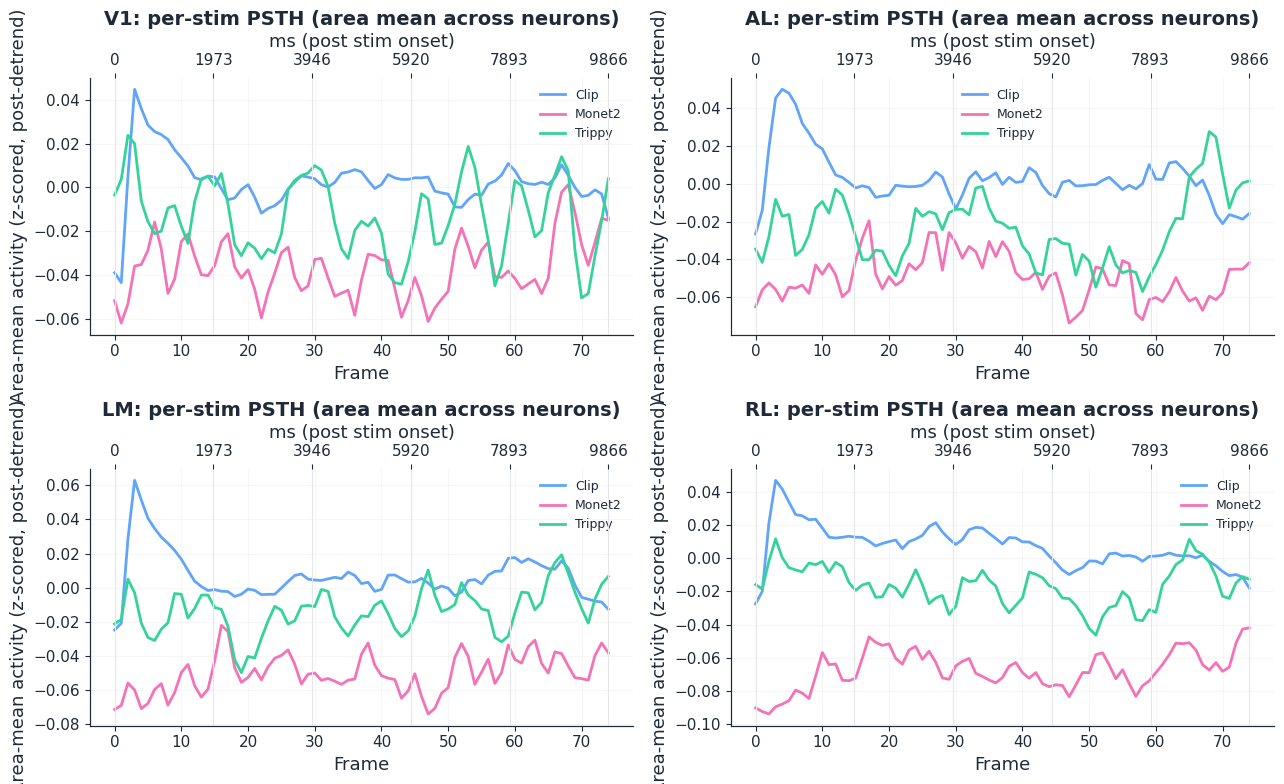

In [5]:
# We need the preprocessed responses + per-area trajectories for PSTH; build them once here
# (Part 1 will use the same outputs).
print("loading + preprocessing responses...")
responses, trial_boundaries, _ = microns_eda.load_session_responses(
    reader, DATADIR, SESSION
)
responses_pp = pca_utils.preprocess_responses(responses, apply_log=False)
trajectories = traj_utils.build_stim_trajectories(
    responses_pp, trial_boundaries, clean_trial_indices,
    meta["brain_areas"], labels, n_frames=N_FRAMES_TRUNCATE,
)
print(f"trajectories built for areas {sorted(trajectories.keys())}")

# Four-panel PSTH (one per area).
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for area, ax in zip(["V1", "AL", "LM", "RL"], axes.flat):
    if area in trajectories:
        traj_utils.plot_psth_per_stim_area(trajectories, area, ax=ax)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "0_5_psth_per_area.png", dpi=150)
plt.show()

### Interpretation

For each area and stimulus class, this curve is built by two successive means: (1) average across all trials of that class frame by frame, giving a `(75, N_neurons)` matrix; (2) average across the neuron axis, giving one number per frame. The y-axis is therefore the area-mean activity at each frame, in z-score units (data was per-neuron z-scored and per-trial detrended upstream, so values hover around 0).

**What we see:** all four areas show a clean Clip onset transient in the first ~10 frames (~1 s), then settle. Monet2 sits visibly below Clip and Trippy throughout the trial in every area; Trippy fluctuates around 0, closer to Clip in mean level. So at this rawest possible temporal view the Clip-vs-synthetic distinction is already obvious (driven by the onset peak), and Monet2 separates from Trippy by a baseline offset. Whether Monet2 and Trippy are also distinguishable at the *geometric* level (not just by their mean activity) is what PCA will test.

## Part 1: Build per-area, per-stimulus trajectories

We've already built `trajectories` above for the PSTH plot. Here we save them to disk for later reload (so subsequent runs of the notebook can skip the slow preprocessing step) and run sanity asserts.

In [6]:
# Sanity asserts on the trajectory shapes.
for area, per_stim in trajectories.items():
    for stim, traj in per_stim.items():
        assert traj.shape[0] == N_FRAMES_TRUNCATE, f"{area}/{stim} wrong n_frames"
        assert not np.isnan(traj).any(), f"{area}/{stim} has NaN"
        assert (traj.std(axis=0) > 0).all(), f"{area}/{stim} has zero-var neurons"
print("trajectory sanity asserts passed.")

# Save to disk for fast reload.
traj_path = RESULTS_DIR / "trajectories.npz"
traj_utils.save_trajectories(trajectories, traj_path)
print(f"saved {traj_path}")

trajectory sanity asserts passed.
saved results/exp2_stim_trajectories/7_5/trajectories.npz


## Part 2: Fit PCA per area on stacked stimulus trajectories

For each area, vertically stack the 3 stimulus matrices into a `(225, n_neurons_in_area)` matrix and fit PCA. The 3 stimuli share a common coordinate system within an area, so trajectories are directly comparable.

**Note on PC1.** PCA finds the directions of largest variance in the stacked data. The single biggest source of variance here is the shared response burst at stimulus onset, all three stimuli show a quick rise at frame 0 followed by a decay (visible in the PSTH plot above). PC1 mostly captures *that shared temporal pattern*, not what distinguishes the three stimuli from each other. Stimulus identity, the feature we care about, lives in lower-variance directions: PC2 and PC3. When reading the trajectory plots, separation along PC2–PC3 is the meaningful signal; separation along PC1 mostly reflects the shared rise-and-decay shape that all three stimuli have in common.

In [7]:
pca_per_area = traj_utils.fit_trajectory_pca(
    trajectories, n_components=N_COMPONENTS, random_state=RANDOM_SEED,
)
print("Per-area PCA fitted:")
for area in sorted(pca_per_area.keys()):
    pca = pca_per_area[area]["pca"]
    top3 = 100 * pca.explained_variance_ratio_[:3].sum()
    top10 = 100 * pca.explained_variance_ratio_[:10].sum()
    print(f"  {area:4s}: top-3 cum var = {top3:5.1f}%   top-10 cum var = {top10:5.1f}%")

Per-area PCA fitted:
  AL  : top-3 cum var =  29.5%   top-10 cum var =  41.3%
  LM  : top-3 cum var =  32.7%   top-10 cum var =  42.3%
  RL  : top-3 cum var =  33.8%   top-10 cum var =  43.4%
  V1  : top-3 cum var =  29.0%   top-10 cum var =  38.6%


The per-area PCA shows that the top 3 components capture only **~29–34 % of the variance** in each area (top 10: ~38–43 %). No dominant direction exists; variance is spread fairly thinly across many components. This means the 2-D and 3-D trajectory plots in the next sections, which use only the top 3 PCs, are missing roughly two-thirds of the population variance. That is precisely why we also compute a *full-feature* distance metric in Part 4: if the top-3 view shows separation but the full-feature view does not, the visualisation is over-promising and the real geometry lives in lower-variance directions.

## Part 3: Visualise V1 trajectories

V1 is our reference area. We plot the three stimulus trajectories in the top-3 PC space. Filled circle marks frame 0, open circle marks the last frame.

**What we're looking for:** do the trajectories peel apart at any point in the trial, or do they trace overlapping paths? PC1 likely captures stimulus-common temporal dynamics (the joint rise/settle); stimulus-specific differences should appear as separation along PC2-3.

**Qualitative shape question:** even when trajectories peel apart, *how* do they peel apart? Parallel curves at different points = stable per-stim representation. Intersecting / diverging curves = dynamic re-coding.

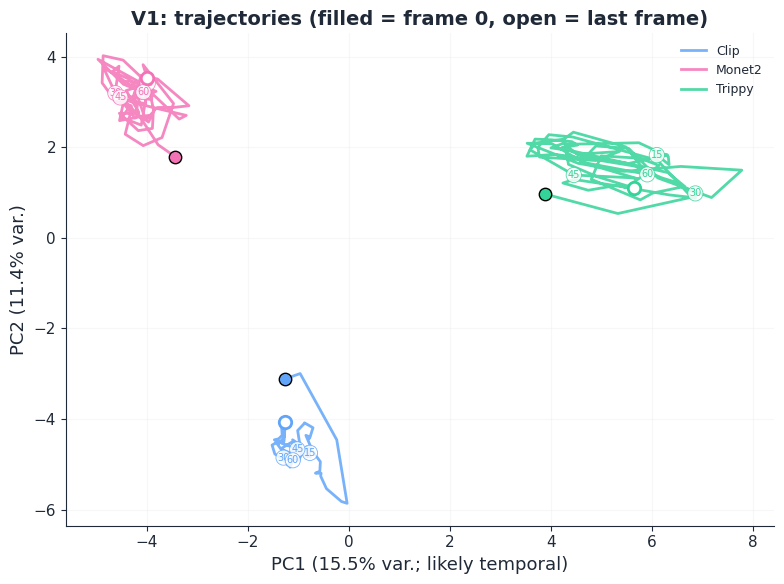

saved figures/exp2_stim_trajectories/7_5/3_v1_trajectory_3d.html


In [8]:
# 2-D trajectory (matplotlib).
fig, ax = plt.subplots(figsize=(8, 6))
traj_utils.plot_trajectory_2d(
    pca_per_area["V1"]["stim_pcs"], "V1", pca_per_area["V1"]["pca"], ax=ax,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "3_v1_trajectory_2d.png", dpi=150)
plt.show()

# 3-D trajectory (Plotly).
fig3d = traj_utils.plot_trajectory_3d_plotly(
    pca_per_area["V1"]["stim_pcs"], "V1", pca_per_area["V1"]["pca"],
)
out_html = FIGURES_DIR / "3_v1_trajectory_3d.html"
fig3d.write_html(str(out_html))
print(f"saved {out_html}")
fig3d.show()

### Interpretation: V1 trajectories

The three trajectories **occupy three distinct regions** of PC1–PC2–PC3 space. Note that this PCA was fit on the stacked class-mean trajectories themselves (3 × 75 points), so the between-class differences are part of the variance it maximises; separation of the three curves in this projection is expected by construction and is not evidence on its own. The statistical test is in Part 5. Clip sits in the bottom-centre, Monet2 in the top-left, Trippy on the right, each stimulus occupies its own region of V1's state space.

**Where the separation lives.** Most of the structure is in the **PC1–PC2 plane**: PC1 (15.5 % var.) cleanly splits Trippy (positive) from Clip and Monet2 (negative), and PC2 (11.4 % var.) splits Monet2 (high) from Clip (low). PC3 adds almost nothing (2.1 % var.), the 3-D plot doesn't reveal any structure that the 2-D plot misses. *Note: this contradicts the prior expectation that PC1 would only carry stimulus-common temporal dynamics, in this session, PC1 is already a stimulus-discriminating axis, not a "shared time" axis.*

**Qualitative shape.** Each trajectory looks like a **tangled blob, not an ordered path**. The frame markers (15, 30, 45, 60) all bunch together inside the cloud, so once the population settles, it doesn't drift, it wiggles around a fixed location for the rest of the 10-second trial. This is a **stable, parallel** representation: each stimulus has a stationary "address" in state space, and the three addresses don't intersect or move toward each other. There's no sign of dynamic re-coding (curves crossing, swapping positions, or converging).

**The one bit of motion that's visible.** The filled circle (frame 0) is consistently displaced from the rest of each cloud, sitting closer to the centre of the plot. This means the population starts each trial near a more "neutral" point and then jumps out to its stimulus-specific blob over the first few frames, exactly the onset transient we saw in the PSTH, now visible as a single trajectory move in state space.

## Part 4: Pairwise distance time courses for V1

For each pair of stimulus trajectories, compute frame-by-frame Euclidean distance. We compute two metrics:

1. **Full-feature distance** (primary): uses all V1 neurons. Honest measure of trajectory separation; not dependent on which directions PCA happens to select.
2. **Top-3 PC distance** (visualisation-aligned check): uses the projection through V1's PCA. Tells us how much of the full separation lives in the dimensions we plotted in Part 3.

The full-feature distance is the primary test. The top-3 PC distance is only a check on the visualisation: because the PCA was fit on the same three class-mean trajectories, distances in that subspace are inflated relative to a label-shuffled null (Part 5 quantifies this), so it cannot be used as evidence on its own. Both raw distances carry a sampling-noise floor of `sqrt(N·(1/n_A + 1/n_B))` (z-scored units) that depends on the trial counts of the pair; the dashed bias-corrected curve is the comparable quantity.

V1 trial tensor shape: (453, 75, 5485)


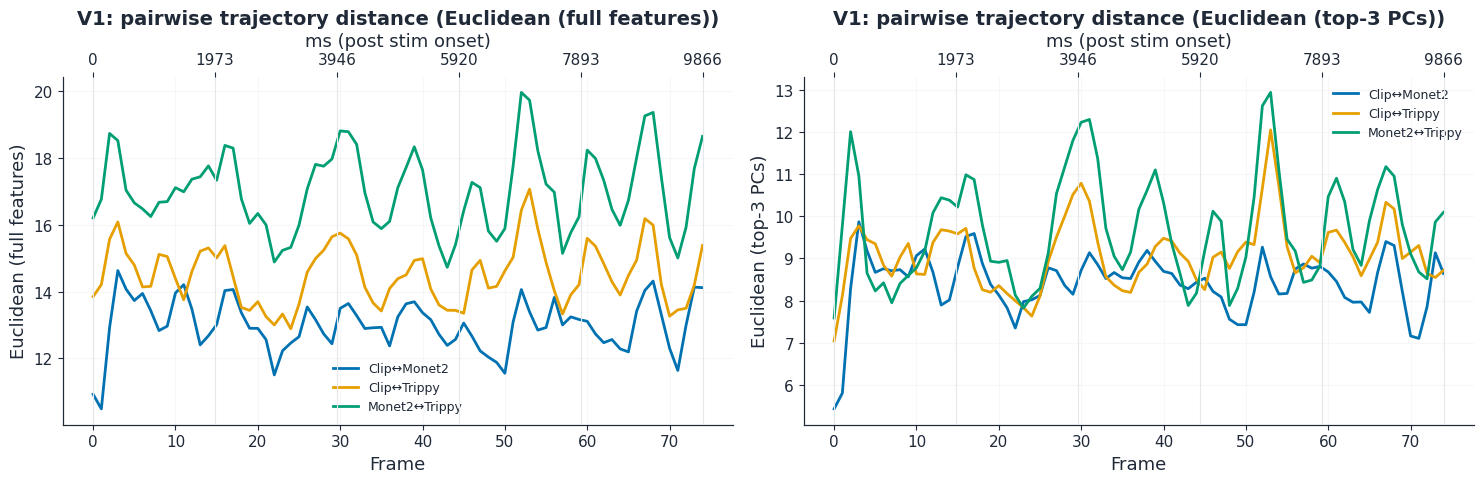

In [9]:
# Build the V1 trial × time × neuron tensor (used by Parts 4-5 + bootstrap + null).
def _build_trial_tensor(responses_pp, trial_boundaries, clean_indices, cols, n_frames):
    out = np.empty((len(clean_indices), n_frames, len(cols)), dtype=np.float64)
    for out_idx, t_idx in enumerate(clean_indices):
        start = int(trial_boundaries[t_idx])
        if start + n_frames > int(trial_boundaries[t_idx + 1]):
            raise ValueError(f"trial {t_idx} is shorter than n_frames={n_frames}")
        out[out_idx] = responses_pp[cols, start:start + n_frames].T
    return out

# Decode area assignments once.
brain_areas_str = np.array([
    s.decode("utf-8") if isinstance(s, bytes) else str(s)
    for s in meta["brain_areas"]
])
v1_cols = np.where(brain_areas_str == "V1")[0]
v1_tensor = _build_trial_tensor(
    responses_pp, trial_boundaries, clean_trial_indices, v1_cols, N_FRAMES_TRUNCATE,
)
print(f"V1 trial tensor shape: {v1_tensor.shape}")  # (453, 75, 5485) for 7_5

# Compute distances (full-feature + top-3 PC).
v1_d_full = traj_utils.pairwise_trajectory_distance(
    trajectories["V1"], metric="full",
)
v1_d_top3 = traj_utils.pairwise_trajectory_distance(
    trajectories["V1"], metric="top_pcs",
    pca=pca_per_area["V1"]["pca"], n_pcs=N_PCS_FOR_DISTANCE,
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
traj_utils.plot_pairwise_distance_time_course(
    v1_d_full, None, "V1", "Euclidean (full features)", ax=axes[0],
)
traj_utils.plot_pairwise_distance_time_course(
    v1_d_top3, None, "V1", "Euclidean (top-3 PCs)", ax=axes[1],
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "4_v1_distance_two_metrics.png", dpi=150)
plt.show()

### Interpretation: V1 distance metrics

**The ordering of the three raw curves is the ordering of their noise floors, not a result.** With z-scored data the expected distance between two class-mean trajectories with *no* true difference is `sqrt(N·(1/n_A + 1/n_B))`: for V1 that is ≈ 17.0 for Monet2↔Trippy (38/38 trials) and ≈ 12.6 for Clip↔Monet2 (377/38). The observed maxima (≈ 20 and ≈ 14.6) sit close to those floors, and Monet2↔Trippy is the "largest" distance only because it has the fewest trials. Raw distances therefore say nothing about which pair is most different; the shuffle null (Part 5) and the bias-corrected curve are what carry information.

**The two metrics also agree on the dynamics:** distances are roughly **flat** across the 75 frames in both panels. There is no obvious rise-and-fall structure, no time window where the trajectories suddenly peel apart and then converge. The trajectories are separated throughout the trial, not just at one phase of the response, which fits the Part 3 picture of three stationary "blobs" in state space.

**The one notable temporal feature** is the very first frame: in both panels, all three pairwise distances are visibly *lower* at frame 0 than from frame 2 onwards (especially Clip↔Monet2 in the full-feature panel, which jumps from ~10.5 to ~14 in two frames). This is the onset transient again, the population starts each trial near a shared "pre-stimulus" location and rapidly moves apart into the three stimulus-specific clouds within the first ~250 ms.

**Where the two metrics differ is in absolute scale.** Full-feature distances span ~11–20 across all 5,485 neurons; top-3 PC distances span ~7–13 across just 3 dimensions. That is expected (more dimensions → larger Euclidean distances). The significant question, *is the separation real or noise?*, can't be answered from these raw curves alone. The shuffle nulls in Part 5 are what tell us whether the gaps we see here are larger than what random label assignments would produce.

## Part 5: Shuffle null and bias-corrected distance on V1

Two statistical checks:

- **Shuffle null** (n=1000, max-distance statistic): if stim labels were random, what max pairwise distance would we expect? The observed max compared to this null gives an empirical p-value per pair. The same null gives the **onset latency**: the first frame at which the *observed* distance exceeds the null's 95th percentile (testing every frame against the null of the max is the max-T correction, so the error rate over the 75 frames stays at 5 %). A pair with p ≥ 0.05 has no onset by construction.
- **Bias-corrected distance** (split-half, 20 random splits): the raw distance `‖mean_A − mean_B‖` is inflated by sampling noise, `sqrt(N·(1/n_A + 1/n_B))` in z-scored units — for V1 that floor is ≈ 17 for Monet2↔Trippy (38/38) and ≈ 12.6 for Clip↔Monet2 (377/38), i.e. most of what the raw curves show. The split-half inner product `⟨mean_A¹ − mean_B¹, mean_A² − mean_B²⟩` is unbiased for the true squared distance, so `max_distance_cv` is the number to compare across pairs and across areas.
- **No bootstrap band.** A class-stratified bootstrap of this distance was drawn in earlier versions; it is *not* a confidence interval for the true distance — a bootstrap resample adds a second draw of the noise term above, so the whole band sits visibly above the observed curve — and it was removed from the figures. `experiment2_utils.bootstrap_distance_envelope` is kept only so old figures can be reproduced.

Decision: a pair is **reliably separated** if p < 0.05 against the shuffle null. (An earlier version also required the bootstrap lower envelope to clear the null's 95th percentile; that criterion fires on pure noise and reported onsets for pairs with p > 0.3, so it was dropped.)

In [10]:
print(f"computing V1 bias-corrected (split-half) distances (n_splits={N_CV_SPLITS})...")
v1_cv_full = traj_utils.crossvalidated_distance(
    v1_tensor, labels, metric="full",
    n_splits=N_CV_SPLITS, seed=RANDOM_SEED + 4,
)
v1_cv_top3 = traj_utils.crossvalidated_distance(
    v1_tensor, labels, metric="top_pcs",
    pca=pca_per_area["V1"]["pca"], n_pcs=N_PCS_FOR_DISTANCE,
    n_splits=N_CV_SPLITS, seed=RANDOM_SEED + 5,
)

print("computing V1 shuffle null (n=100)...")
v1_null_full = traj_utils.shuffle_null_max_distance(
    v1_tensor, labels, metric="full",
    n_shuffles=N_SHUFFLES, seed=RANDOM_SEED + 2,
)
v1_null_top3 = traj_utils.shuffle_null_max_distance(
    v1_tensor, labels, metric="top_pcs",
    pca=pca_per_area["V1"]["pca"], n_pcs=N_PCS_FOR_DISTANCE,
    n_shuffles=N_SHUFFLES, seed=RANDOM_SEED + 3,
)

computing V1 bias-corrected (split-half) distances (n_splits=20)...
computing V1 shuffle null (n=100)...


In [11]:
# Per-pair p-values + onset latencies.
# V1-only preview; the Holm-corrected p over all areas x pairs is computed in Part 7's CSV cell.
def _summarize_v1(distances, cv_distances, nulls):
    rows = []
    for pair, d in distances.items():
        observed_max = float(d.max())
        null_p95 = float(np.percentile(nulls[pair], 95))
        p = float((1 + (nulls[pair] >= observed_max).sum()) / (1 + len(nulls[pair])))
        # Onset: first frame where the OBSERVED curve exceeds the null of the max.
        latency = traj_utils.compute_onset_latency(d, nulls[pair], alpha=0.05)
        rows.append({
            "pair": "/".join(sorted(pair)),
            "max_observed": observed_max,
            "max_cv": float(cv_distances[pair].max()),
            "null_p95": null_p95,
            "p_value": p,
            "onset_frame": latency,
            "onset_ms": frame_to_ms(latency) if latency is not None else None,
        })
    return pd.DataFrame(rows)

print("=== V1 full-feature ===")
print(_summarize_v1(v1_d_full, v1_cv_full, v1_null_full).to_string(index=False))
print("\n=== V1 top-3 PCs ===")
print(_summarize_v1(v1_d_top3, v1_cv_top3, v1_null_top3).to_string(index=False))

=== V1 full-feature ===
         pair  max_observed    max_cv  null_p95  p_value  onset_frame    onset_ms
  Clip/Monet2     14.627428  9.906821 16.688884 0.534466          NaN         NaN
  Clip/Trippy     17.064840 11.278518 16.698811 0.028971         53.0 7066.666667
Monet2/Trippy     19.959935 12.449239 21.460496 0.337662          NaN         NaN

=== V1 top-3 PCs ===
         pair  max_observed    max_cv  null_p95  p_value  onset_frame  onset_ms
  Clip/Monet2      9.870586  9.750868  4.921871 0.000999            0       0.0
  Clip/Trippy     12.052829 11.857905  4.963488 0.000999            0       0.0
Monet2/Trippy     12.943261 12.685015  6.667295 0.000999            0       0.0


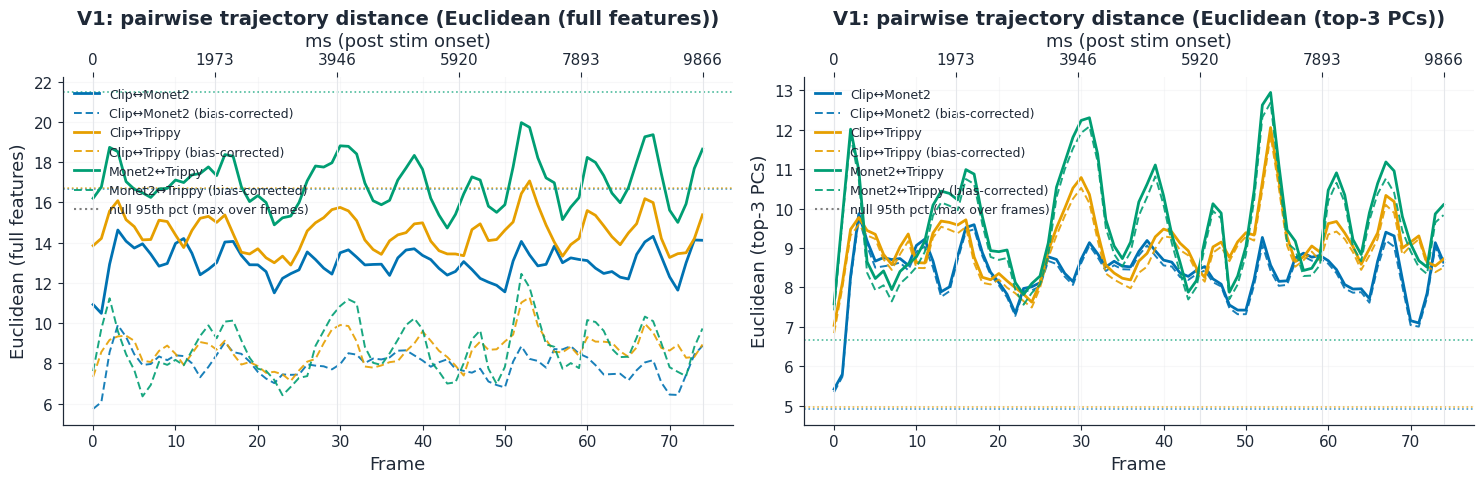

In [12]:
# Two-panel figure: raw (solid), bias-corrected (dashed), null 95th pct (dotted).
v1_null_p95_full = {p: float(np.percentile(v1_null_full[p], 95)) for p in v1_null_full}
v1_null_p95_top3 = {p: float(np.percentile(v1_null_top3[p], 95)) for p in v1_null_top3}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
traj_utils.plot_pairwise_distance_time_course(
    v1_d_full, None, "V1", "Euclidean (full features)",
    null_p95=v1_null_p95_full, cv_distances=v1_cv_full, ax=axes[0],
)
traj_utils.plot_pairwise_distance_time_course(
    v1_d_top3, None, "V1", "Euclidean (top-3 PCs)",
    null_p95=v1_null_p95_top3, cv_distances=v1_cv_top3, ax=axes[1],
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "5_v1_distance_with_null.png", dpi=150)
plt.show()

### Interpretation: V1 statistical results

- *Full-feature distance* (all 5,485 V1 neurons, the primary test): **no pair reaches reliable separation.** Clip↔Trippy has an uncorrected p = 0.029 (observed maximum 17.06 against a null 95th percentile of 16.70), Clip↔Monet2 p = 0.53, Monet2↔Trippy p = 0.34. After Holm correction over the 12 area × pair tests of this metric, Clip↔Trippy is at p_holm = 0.32; no onset is reported for any pair. The raw curves sit on or below the dotted null thresholds: randomly shuffled labels produce distances as large as the real ones.
- *Bias-corrected distance* (dashed): Monet2↔Trippy 12.4, Clip↔Trippy 11.3, Clip↔Monet2 9.9 at their maxima, against raw maxima of 20.0, 17.1 and 14.6. The gap between the two is the sampling-noise floor, largest for the 38/38 pair.
- *Top-3 PC distance* (only the 3 directions PCA picked): all three pairs sit far above their null lines (p = 0.001). This is expected by construction, not evidence: the PCA was fit on the same three class-mean trajectories, so the top directions were chosen to spread them apart, and label-shuffled trajectories projected through that fit cannot compete. The top-3 rows in the CSV are kept as a visualisation check only.

**Bottom line.** With the time axis preserved, this linear, full-population analysis does not detect a difference between any two stimulus classes in V1 at the family-wise 5 % level, and in particular no Monet2/Trippy difference — consistent with experiment 1, where the two parametric stimuli overlapped in PC1–2 while a decoder still told all three classes apart. The three-cloud picture in Part 3 is a property of the projection. The next two checks ask whether the higher visual areas behave differently and whether population size matters.


## Part 6: Repeat on AL, LM, RL

Apply Parts 3-5 to the higher visual areas: 2-D + 3-D scatters, full-feature + top-3 PC distance time courses with bias-corrected curves and shuffle nulls (1000 permutations each).

In [13]:
all_area_results = {
    "V1": {
        "tensor": v1_tensor,
        "trajectories": trajectories["V1"],
        "pca": pca_per_area["V1"]["pca"],
        "stim_pcs": pca_per_area["V1"]["stim_pcs"],
        "distances_full": v1_d_full,
        "distances_top3": v1_d_top3,
        "cv_full": v1_cv_full,
        "cv_top3": v1_cv_top3,
        "null_full": v1_null_full,
        "null_top3": v1_null_top3,
        "n_neurons": v1_tensor.shape[2],
    },
}

for area in ["AL", "LM", "RL"]:
    print(f"\n=== {area} ===")
    cols = np.where(brain_areas_str == area)[0]
    tensor = _build_trial_tensor(
        responses_pp, trial_boundaries, clean_trial_indices, cols, N_FRAMES_TRUNCATE,
    )
    print(f"  trial tensor shape: {tensor.shape}")

    pca_a = pca_per_area[area]["pca"]
    stim_pcs_a = pca_per_area[area]["stim_pcs"]
    d_full = traj_utils.pairwise_trajectory_distance(
        trajectories[area], metric="full",
    )
    d_top3 = traj_utils.pairwise_trajectory_distance(
        trajectories[area], metric="top_pcs",
        pca=pca_a, n_pcs=N_PCS_FOR_DISTANCE,
    )
    print(f"  bias-corrected distances (n_splits={N_CV_SPLITS})...")
    cv_full = traj_utils.crossvalidated_distance(
        tensor, labels, metric="full",
        n_splits=N_CV_SPLITS, seed=RANDOM_SEED + 50 + ord(area[0]),
    )
    cv_top3 = traj_utils.crossvalidated_distance(
        tensor, labels, metric="top_pcs",
        pca=pca_a, n_pcs=N_PCS_FOR_DISTANCE,
        n_splits=N_CV_SPLITS, seed=RANDOM_SEED + 60 + ord(area[0]),
    )
    print(f"  shuffle null (n={N_SHUFFLES})...")
    null_full = traj_utils.shuffle_null_max_distance(
        tensor, labels, metric="full",
        n_shuffles=N_SHUFFLES, seed=RANDOM_SEED + 30 + ord(area[0]),
    )
    null_top3 = traj_utils.shuffle_null_max_distance(
        tensor, labels, metric="top_pcs",
        pca=pca_a, n_pcs=N_PCS_FOR_DISTANCE,
        n_shuffles=N_SHUFFLES, seed=RANDOM_SEED + 40 + ord(area[0]),
    )
    all_area_results[area] = {
        "tensor": tensor,
        "trajectories": trajectories[area],
        "pca": pca_a,
        "stim_pcs": stim_pcs_a,
        "distances_full": d_full,
        "distances_top3": d_top3,
        "cv_full": cv_full,
        "cv_top3": cv_top3,
        "null_full": null_full,
        "null_top3": null_top3,
        "n_neurons": tensor.shape[2],
    }


=== AL ===
  trial tensor shape: (453, 75, 414)
  bias-corrected distances (n_splits=20)...
  shuffle null (n=1000)...

=== LM ===
  trial tensor shape: (453, 75, 1262)
  bias-corrected distances (n_splits=20)...
  shuffle null (n=1000)...

=== RL ===
  trial tensor shape: (453, 75, 1033)
  bias-corrected distances (n_splits=20)...
  shuffle null (n=1000)...


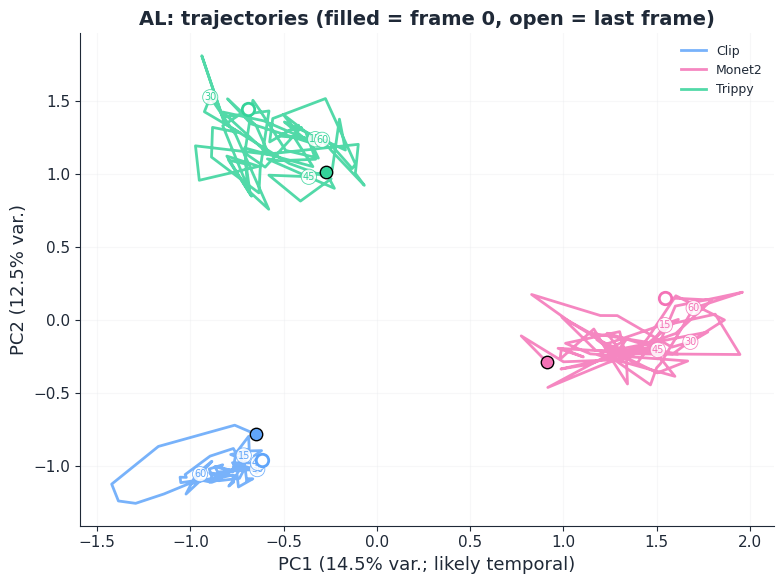

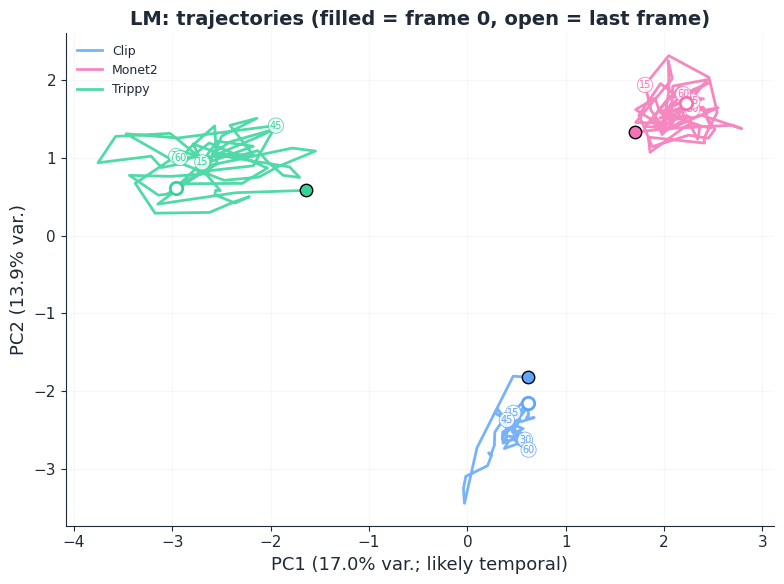

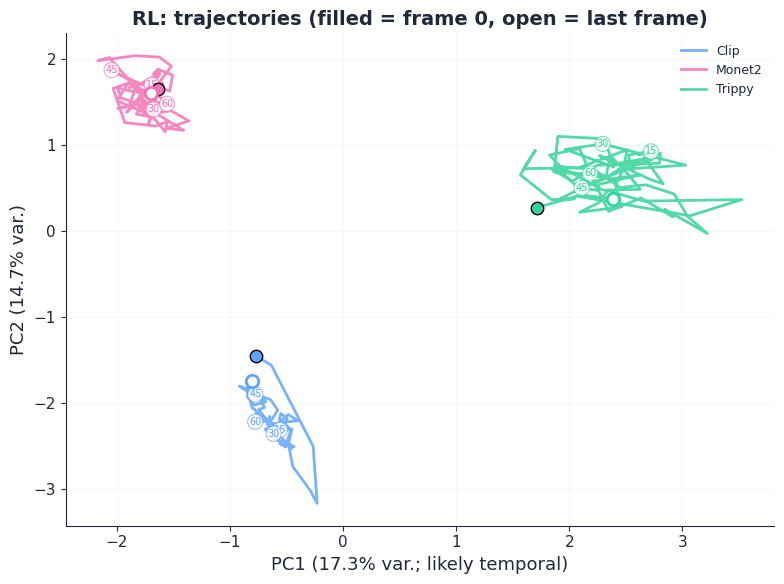

In [14]:
# Per-area scatters (2-D + 3-D Plotly).
for area in ["AL", "LM", "RL"]:
    res = all_area_results[area]
    fig, ax = plt.subplots(figsize=(8, 6))
    traj_utils.plot_trajectory_2d(res["stim_pcs"], area, res["pca"], ax=ax)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"6_{area.lower()}_trajectory_2d.png", dpi=150)
    plt.show()

    fig3d = traj_utils.plot_trajectory_3d_plotly(res["stim_pcs"], area, res["pca"])
    fig3d.write_html(str(FIGURES_DIR / f"6_{area.lower()}_trajectory_3d.html"))

### Interpretation: AL, LM, RL trajectories

The same picture from V1 reproduces in all three higher visual areas: the three class-mean trajectories occupy distinct regions of PC1–PC2 space. As for V1, the PCA is fit on those same three trajectories, so this separation is expected by construction; the test is in Part 7. Each area lays the three clouds out slightly differently, Trippy and Monet2 swap left/right between AL and LM, for example, but the structural finding is the same: each stimulus occupies its own stationary region of state space. Frame markers (15, 30, 45, 60) bunch together inside each blob, frame 0 sits offset from the bulk (the onset transient again), and PC1–PC2 carry essentially all the visible structure (variance shares 14–17 % and 12–15 % respectively, with PC3 again contributing little).

So at the projected-space level, AL, LM and RL look just as cleanly separated as V1. **Whether that separation survives an honest statistical test is the question Parts 7 and 8 will settle**: and given V1's verdict (clean PC-space picture, no separation at full-feature scale), we should expect the same caveat to apply here.

## Part 7: Cross-area Monet2↔Trippy summary (headline)

The headline figure: Monet2↔Trippy distance time course for all four areas on shared axes, with the bias-corrected curve and each area's null threshold. Two panels: full-feature distance (primary) and top-3 PC distance (visualisation check).

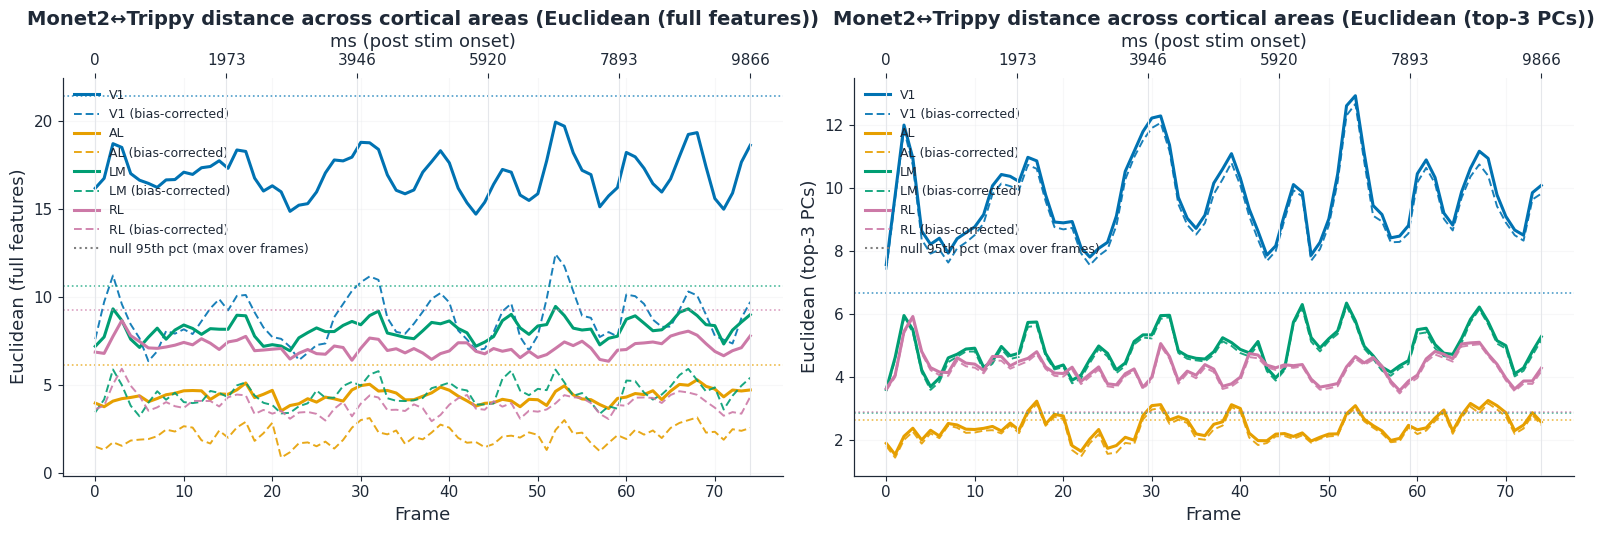

In [15]:
m2t_pair = frozenset({"Monet2", "Trippy"})
m2t_full = {area: res["distances_full"][m2t_pair] for area, res in all_area_results.items()}
m2t_cv_full = {area: res["cv_full"][m2t_pair] for area, res in all_area_results.items()}
m2t_null_full = {area: float(np.percentile(res["null_full"][m2t_pair], 95)) for area, res in all_area_results.items()}
m2t_top3 = {area: res["distances_top3"][m2t_pair] for area, res in all_area_results.items()}
m2t_cv_top3 = {area: res["cv_top3"][m2t_pair] for area, res in all_area_results.items()}
m2t_null_top3 = {area: float(np.percentile(res["null_top3"][m2t_pair], 95)) for area, res in all_area_results.items()}

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
traj_utils.plot_cross_area_monet2_trippy(
    m2t_full, None, "Euclidean (full features)",
    per_area_cv=m2t_cv_full, per_area_null_p95=m2t_null_full, ax=axes[0],
)
traj_utils.plot_cross_area_monet2_trippy(
    m2t_top3, None, "Euclidean (top-3 PCs)",
    per_area_cv=m2t_cv_top3, per_area_null_p95=m2t_null_top3, ax=axes[1],
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "7_cross_area_monet2_trippy.png", dpi=150)
plt.show()

In [16]:
# Per-area, per-pair, per-metric summary CSV.
def _build_metric_rows(results, analysis_label):
    """One row per (area, metric, pair).

    Columns: ``max_distance_observed`` (raw, noise-inflated), ``max_distance_cv``
    (split-half bias-corrected, comparable across pairs and areas),
    ``max_distance_null_p95`` and ``empirical_p_value`` (observed max vs the
    shuffle null of the max), ``onset_frame`` / ``onset_ms`` (first frame at
    which the *observed* curve exceeds the null-of-the-max 95th percentile;
    ``None`` whenever the pair is not significant after Holm), ``p_holm`` and
    ``n_tests`` (Holm over the 12 tests of one metric).
    """
    rows = []
    for area, res in results.items():
        for metric_label, dist_key, cv_key, null_key in [
            ("full", "distances_full", "cv_full", "null_full"),
            ("top3_pc", "distances_top3", "cv_top3", "null_top3"),
        ]:
            for pair in res[dist_key]:
                d = res[dist_key][pair]
                cv = res[cv_key][pair]
                null = res[null_key][pair]
                obs_max = float(d.max())
                p95 = float(np.percentile(null, 95))
                p = float((1 + (null >= obs_max).sum()) / (1 + len(null)))
                lat = traj_utils.compute_onset_latency(d, null, alpha=0.05)
                rows.append({
                    "area": area,
                    "n_neurons": res["n_neurons"],
                    "pair": "/".join(sorted(pair)),
                    "metric": metric_label,
                    "max_distance_observed": obs_max,
                    "max_distance_cv": float(cv.max()),
                    "max_distance_null_p95": p95,
                    "empirical_p_value": p,
                    "onset_frame": lat,
                    "onset_ms": frame_to_ms(lat) if lat is not None else None,
                    "analysis": analysis_label,
                })
    # Holm over the family of one metric (4 areas x 3 pairs = 12 tests).
    # Onsets are reported only for pairs that survive the correction.
    df = pd.DataFrame(rows)
    for metric_label in ("full", "top3_pc"):
        fam = df["metric"] == metric_label
        df.loc[fam, "p_holm"] = pca_utils.holm_adjust(df.loc[fam, "empirical_p_value"])
        df.loc[fam, "n_tests"] = int(fam.sum())
    not_sig = df["p_holm"] >= 0.05
    df.loc[not_sig, ["onset_frame", "onset_ms"]] = None
    return df.to_dict("records")

results_df = pd.DataFrame(_build_metric_rows(all_area_results, "all_neurons"))
csv_path = RESULTS_DIR / "trajectory_metrics.csv"
results_df.to_csv(csv_path, index=False)
print(f"wrote {csv_path}  ({len(results_df)} rows)")
results_df

wrote results/exp2_stim_trajectories/7_5/trajectory_metrics.csv  (24 rows)


,area,n_neurons,pair,metric,max_distance_observed,max_distance_cv,max_distance_null_p95,empirical_p_value,onset_frame,onset_ms,analysis,p_holm,n_tests
0,V1,5485,Clip/Monet2,full,14.627428,9.906821,16.688884,0.534466,NaN,NaN,all_neurons,1.000000,12.0
1,V1,5485,Clip/Trippy,full,17.064840,11.278518,16.698811,0.028971,NaN,NaN,all_neurons,0.318681,12.0
2,V1,5485,Monet2/Trippy,full,19.959935,12.449239,21.460496,0.337662,NaN,NaN,all_neurons,1.000000,12.0
3,V1,5485,Clip/Monet2,top3_pc,9.870586,9.750868,4.921871,0.000999,0.0,0.000000,all_neurons,0.011988,12.0
4,V1,5485,Clip/Trippy,top3_pc,12.052829,11.857905,4.963488,0.000999,0.0,0.000000,all_neurons,0.011988,12.0
5,V1,5485,Monet2/Trippy,top3_pc,12.943261,12.685015,6.667295,0.000999,0.0,0.000000,all_neurons,0.011988,12.0
6,AL,414,Clip/Monet2,full,4.283941,3.176816,4.911938,0.412587,NaN,NaN,all_neurons,1.000000,12.0
7,AL,414,Clip/Trippy,full,4.407430,2.898268,4.931036,0.310689,NaN,NaN,all_neurons,1.000000,12.0
8,AL,414,Monet2/Trippy,full,5.304799,3.163057,6.170000,0.776224,NaN,NaN,all_neurons,1.000000,12.0
9,AL,414,Clip/Monet2,top3_pc,3.242431,3.200333,1.982622,0.000999,2.0,266.666667,all_neurons,0.011988,12.0


### Interpretation: cross-area headline

The picture is the same in all four areas: **Monet2↔Trippy never reaches reliable separation under the full-feature test.** The observed maximum sits below the shuffle-null 95th percentile in every region (uncorrected p: V1 0.34, AL 0.78, LM 0.53, RL 0.31; Holm-adjusted 1.0 everywhere), so the question "which area separates them first?" has no answer: none does. Across all 12 area × pair tests of the full-feature metric the smallest Holm-adjusted p is 0.12 (RL Clip↔Trippy, raw p = 0.010), followed by V1 Clip↔Trippy (raw 0.029, p_holm 0.32); nothing crosses 0.05 and no onset is reported.

The bias-corrected curves (dashed) show what the raw ones hide: the raw Monet2↔Trippy maxima (V1 19.96, LM 9.48, RL 8.68, AL 5.30) are largely the `sqrt(N·2/38)` noise floor of a 38-versus-38-trial comparison, and the corrected values (12.4, 5.9, 5.9, 3.2) still scale with the number of neurons in each area, so they do not rank the areas either; Part 8 matches populations for that.

The top-3 PC panel shows positive results everywhere, but these carry the bias identified for V1 (PCA fit on the real class means, shuffled data projected through the same fit) and are not used.

**Conclusion.** In none of the four recorded areas of this session does the linear, full-population distance detect a Monet2/Trippy difference, with or without the time axis. This is a statement about four areas of one session of one animal, with 38 trials per parametric stimulus; whether it reflects matched low-level statistics of the two stimuli, the trial count, or a limit of linear distances between class means was not tested here.


## Part 8: Equal-population control

V1 has ~13× more neurons than AL. Distances scale with population size. We subsample V1, LM, RL down to AL's neuron count (414), 20 random subsamples each, and check whether the cross-area Monet2↔Trippy ranking from Part 7 survives population matching.

For compute reasons, **shuffle nulls are NOT recomputed per subsample**, so nothing in this part is a significance statement. Raw distances at matched population are compared descriptively (median ± IQR over the 20 subsamples); the bias-corrected `max_distance_cv` is the quantity that is comparable across areas, because the raw distance carries a noise floor of `sqrt(414·(1/n_A + 1/n_B))`.

In [20]:
n_match = all_area_results["AL"]["n_neurons"]
print(f"n_match (AL n_neurons, read from data) = {n_match}")

matched_results: dict[str, list[dict]] = {"AL": [{
    "trajectories": all_area_results["AL"]["trajectories"],
    "distances_full": all_area_results["AL"]["distances_full"],
    "distances_top3_pc": all_area_results["AL"]["distances_top3"],
    "distances_cv_full": all_area_results["AL"]["cv_full"],
}]}

for area in ["V1", "LM", "RL"]:
    print(f"\n=== {area} (population matched, {N_POPULATION_SUBSAMPLES} subsamples) ===")
    matched_results[area] = traj_utils.subsample_population_run_pipeline(
        area_name=area,
        trial_tensor=all_area_results[area]["tensor"],
        labels=labels,
        n_match=n_match,
        n_subsamples=N_POPULATION_SUBSAMPLES,
        n_components=N_COMPONENTS,
        seed=RANDOM_SEED + ord(area[0]),
    )
    print(f"  done, {len(matched_results[area])} subsamples")

n_match (AL n_neurons, read from data) = 414

=== V1 (population matched, 20 subsamples) ===
  done, 20 subsamples

=== LM (population matched, 20 subsamples) ===
  done, 20 subsamples

=== RL (population matched, 20 subsamples) ===
  done, 20 subsamples


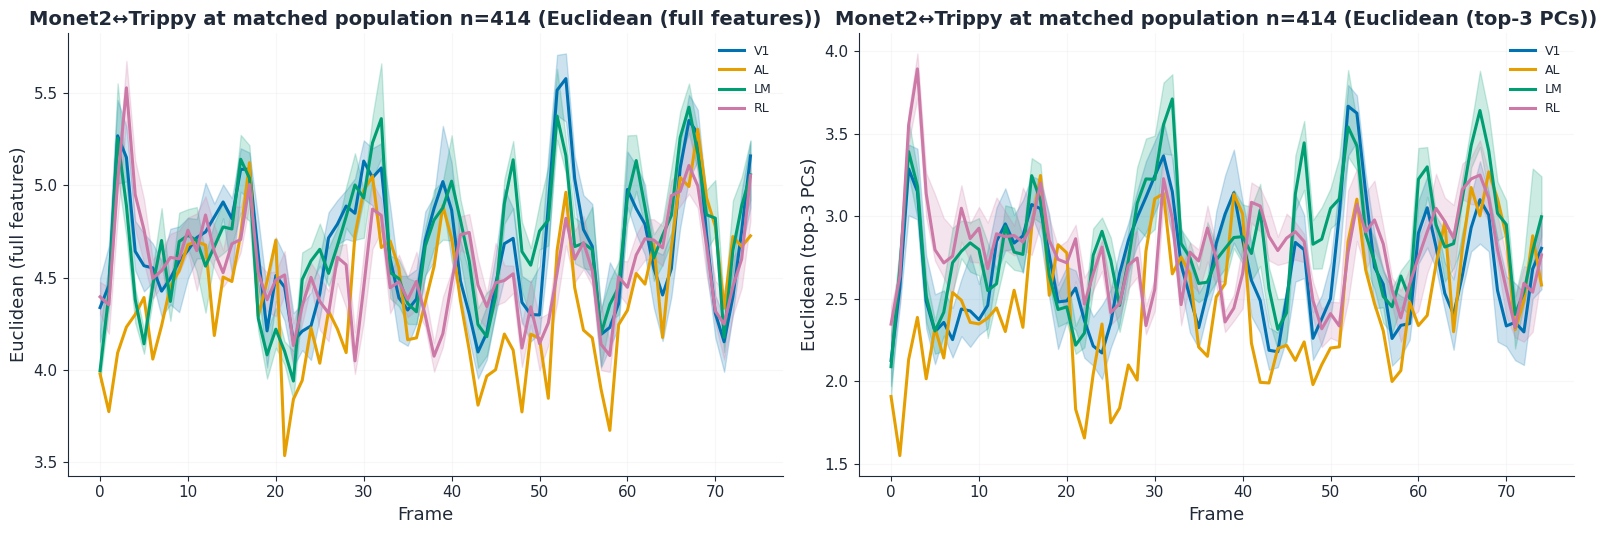

In [21]:
# Cross-area Monet2↔Trippy under matching: median + IQR over subsamples.
m2t_pair = frozenset({"Monet2", "Trippy"})
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for ax, metric_key, metric_label in [
    (axes[0], "distances_full", "Euclidean (full features)"),
    (axes[1], "distances_top3_pc", "Euclidean (top-3 PCs)"),
]:
    for area in ["V1", "AL", "LM", "RL"]:
        per_sub = matched_results[area]
        # Stack distances across subsamples.
        arr = np.array([d[metric_key][m2t_pair] for d in per_sub])
        median = np.median(arr, axis=0)
        x = np.arange(len(median))
        palette = {"V1": "#0072B2", "AL": "#E69F00", "LM": "#009E73", "RL": "#CC79A7"}
        ax.plot(x, median, "-", color=palette[area], linewidth=2.2, label=area)
        if arr.shape[0] > 1:
            q25 = np.quantile(arr, 0.25, axis=0)
            q75 = np.quantile(arr, 0.75, axis=0)
            ax.fill_between(x, q25, q75, color=palette[area], alpha=0.2)
    ax.set_xlabel("Frame")
    ax.set_ylabel(metric_label)
    ax.set_title(f"Monet2↔Trippy at matched population n={n_match} ({metric_label})")
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "8_population_matched_monet2_trippy.png", dpi=150)
plt.show()

In [22]:
# Append matched-population rows to the per-session CSV.
matched_rows = []
for area, sub_list in matched_results.items():
    n_n = n_match
    for metric_label, key in [("full", "distances_full"), ("top3_pc", "distances_top3_pc")]:
        # Aggregate per pair across subsamples.
        pair_keys = list(sub_list[0][key].keys())
        for pair in pair_keys:
            arr = np.array([d[key][pair] for d in sub_list])
            obs_max_per_sub = arr.max(axis=1)
            if key == "distances_full":
                cv_max_per_sub = np.array([d["distances_cv_full"][pair].max() for d in sub_list])
                cv_median = float(np.median(cv_max_per_sub))
            else:
                cv_median = np.nan
            matched_rows.append({
                "area": area,
                "n_neurons": n_n,
                "pair": "/".join(sorted(pair)),
                "metric": metric_label,
                "max_distance_observed": float(np.median(obs_max_per_sub)),
                "max_distance_cv": cv_median,
                "max_distance_null_p95": np.nan,
                "empirical_p_value": np.nan,
                "onset_frame": None,
                "onset_ms": None,
                "analysis": "equal_population",
            })
existing = pd.read_csv(csv_path) if csv_path.exists() else pd.DataFrame()
existing = existing[existing["analysis"] != "equal_population"] if len(existing) else existing
combined = pd.concat([existing, pd.DataFrame(matched_rows)], ignore_index=True)
combined.to_csv(csv_path, index=False)
print(f"wrote {csv_path}  ({len(combined)} rows total)")

wrote results/exp2_stim_trajectories/7_5/trajectory_metrics.csv  (48 rows total)


/var/folders/y_/7gd_6b7d7h9b8772krl0vj4m0000gn/T/ipykernel_34412/509598441.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat([existing, pd.DataFrame(matched_rows)], ignore_index=True)


### Interpretation: equal-population

**The cross-area differences from Part 7 disappear once population size is equalised.** In Part 7's full-feature panel V1 sat at ~20, LM at ~10, RL at ~9, AL at ~5. Here, with every area subsampled to AL's 414 neurons, the Monet2↔Trippy maxima are 5.73 (V1), 5.68 (LM), 5.53 (RL) and 5.30 (AL) raw, and 3.73 / 3.81 / 3.72 / 3.16 bias-corrected — one band. V1's lead was its neuron count.

**What this means.** V1 wasn't actually doing anything special in Part 7: it just had ~13× more neurons than AL, and Euclidean distance grows mechanically with population size (more dimensions to be apart in). Once that mechanical advantage is removed, V1 looks indistinguishable from LM and RL.

**The one residual difference.** AL sits slightly below the other three (bias-corrected 3.16 against 3.7–3.8). AL is a single un-subsampled curve while V1/LM/RL are medians over 20 subsamples, and no null is computed per subsample, so this is a descriptive difference within the subsample-to-subsample spread (the shaded IQR bands), not a tested one.

**Does this rescue the headline?** No. The matched raw distances (≈ 5.3–5.7) are close to the noise floor for 414 neurons and 38/38 trials, `sqrt(414·(2/38)) ≈ 4.7`, and the bias-corrected values (3.2–3.8) are small and equal across areas. Population matching confirms that no area, given the same number of neurons, separates the two parametric stimuli. The Monet2/Trippy still collapses; population matching just confirms that no area, when given an equal-sized neural population, breaks out of it. The problem isn't "where" in cortex, it's that linear Euclidean geometry, even with the time axis preserved, can't separate these two synthetic stimuli regardless of which area you look at.

## Part 9: Clip-trial subsampling sanity check (V1 only)

Clip has 377 trials, Monet2 and Trippy have only 38 each. Clip's trajectory is therefore much smoother than the synthetics', could the apparent Clip↔synthetic distances reflect this asymmetry rather than real geometric separation?

We subsample Clip down to 38 trials, repeat the V1 trajectory + distance computation 20 times, and compare to the all-Clip version.

In [23]:
print(f"V1 Clip-subsampling: {N_CLIP_SUBSAMPLES} subsamples to 38 trials each...")
clip_subsamples = traj_utils.subsample_clip_trials_run_pipeline(
    trial_tensor=v1_tensor,
    labels=labels,
    n_clip_target=38,  # match minority count
    n_subsamples=N_CLIP_SUBSAMPLES,
    n_components=N_COMPONENTS,
    seed=RANDOM_SEED + 100,
)
print(f"  done, {len(clip_subsamples)} subsamples")

V1 Clip-subsampling: 20 subsamples to 38 trials each...
  done, 20 subsamples


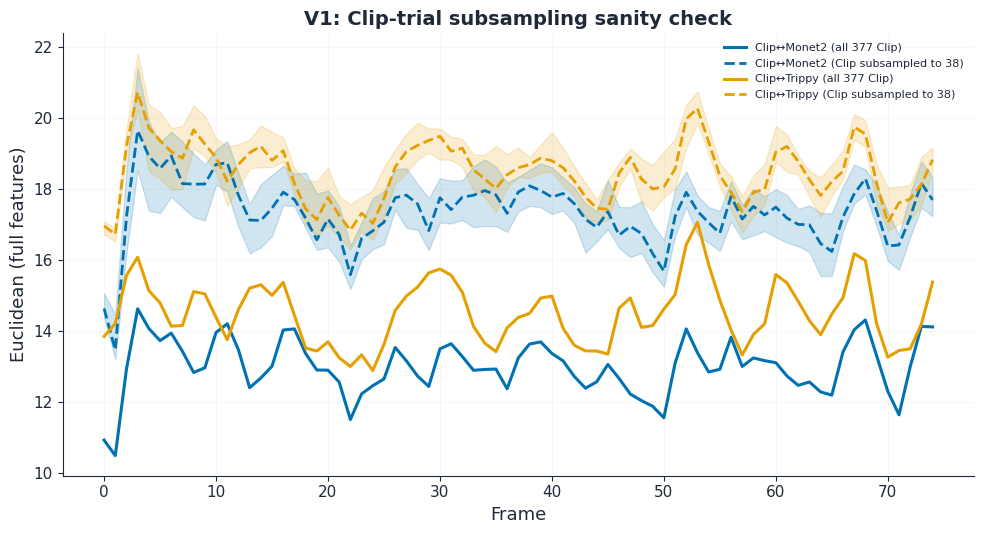

In [24]:
# Compare full-Clip vs subsampled-Clip distance time courses.
fig, ax = plt.subplots(figsize=(10, 5.5))
sub_distances_full = [s["distances_full"] for s in clip_subsamples]
traj_utils.plot_clip_subsampling_comparison(
    full_distances=v1_d_full,
    subsampled_distances_list=sub_distances_full,
    metric_label="Euclidean (full features)",
    ax=ax,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "9_v1_clip_subsampling.png", dpi=150)
plt.show()

In [25]:
# Append clip-matched rows to the CSV.
clip_rows = []
n_n = v1_tensor.shape[2]
for metric_label, key in [("full", "distances_full"), ("top3_pc", "distances_top3_pc")]:
    pair_keys = list(clip_subsamples[0][key].keys())
    for pair in pair_keys:
        arr = np.array([d[key][pair] for d in clip_subsamples])
        obs_max_per_sub = arr.max(axis=1)
        if key == "distances_full":
            cv_max_per_sub = np.array([d["distances_cv_full"][pair].max() for d in clip_subsamples])
            cv_median = float(np.median(cv_max_per_sub))
        else:
            cv_median = np.nan
        clip_rows.append({
            "area": "V1",
            "n_neurons": n_n,
            "pair": "/".join(sorted(pair)),
            "metric": metric_label,
            "max_distance_observed": float(np.median(obs_max_per_sub)),
            "max_distance_cv": cv_median,
            "max_distance_null_p95": np.nan,
            "empirical_p_value": np.nan,
            "onset_frame": None,
            "onset_ms": None,
            "analysis": "clip_matched",
        })
existing = pd.read_csv(csv_path)
existing = existing[existing["analysis"] != "clip_matched"]
combined = pd.concat([existing, pd.DataFrame(clip_rows)], ignore_index=True)
combined.to_csv(csv_path, index=False)
print(f"wrote {csv_path}  ({len(combined)} rows total)")

wrote results/exp2_stim_trajectories/7_5/trajectory_metrics.csv  (54 rows total)


/var/folders/y_/7gd_6b7d7h9b8772krl0vj4m0000gn/T/ipykernel_34412/3450925205.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat([existing, pd.DataFrame(clip_rows)], ignore_index=True)


### Interpretation: Clip subsampling

**The result goes the *opposite* way from what we expected, distances go UP when Clip is matched to 38 trials, not down.**

Looking at the plot: the solid lines (original, 377 Clip trials) sit at ~12–14 for Clip↔Monet2 and ~13–16 for Clip↔Trippy. The dashed lines (Clip subsampled to 38) sit much higher, at ~17–19 and ~17–20 respectively. Subsampling pushed both pair-distances *up* by 4–5 units, well outside the IQR shading.

**Why does this happen?** It's a noise effect, not a signal-strength effect. A trial-averaged trajectory built from 377 trials is very smooth, the average is a precise estimate of the true Clip response. A trial-averaged trajectory built from only 38 trials is noisier. With 377 trials in the original Clip, the noise on Clip's side is tiny; with 38 trials each in Monet2/Trippy, only their noise contributes meaningfully. Once Clip is also dropped to 38 trials, *both* sides contribute noise, so the measured distance inflates, even though the true geometric separation hasn't changed.

**What this means:** the bias-corrected distance makes the point directly. Clip↔Monet2 goes from 14.6 raw / 9.9 corrected with 377 Clip trials to 20.1 raw / 10.5 corrected with 38 (Clip↔Trippy: 17.1 / 11.3 to 21.1 / 11.7). The raw value inflates by a third; the corrected one barely moves. So the Clip-versus-parametric-stimulus difference measured on the full Clip set is not an artefact of the unequal trial counts — although note that on the full-feature test it does not reach family-wise significance in V1 either (Part 5).

**Important caveat.** This control says nothing about the Monet2↔Trippy pair, which was always computed at 38 vs 38 trials and so has no asymmetry to worry about. The Monet2/Trippy collapse from Parts 5 and 7 stands. This subsampling sanity check just rules out one possible explanation for the *Clip↔synthetic* part of the picture, it doesn't rescue the synthetic-vs-synthetic problem.

## Part 10: Cross-session aggregation

Reads `results/exp2_stim_trajectories/{session}/trajectory_metrics.csv` for every session present and produces a comparison plot. With one session this is a single-session view; with ≥2 sessions, a cross-session comparison.

To replicate on another session: change `SESSION` in the configuration block at the top, restart the kernel, and re-run the notebook. Outputs go to per-session subdirectories.

found 1 session(s), wrote results/exp2_stim_trajectories/cross_session_summary.csv


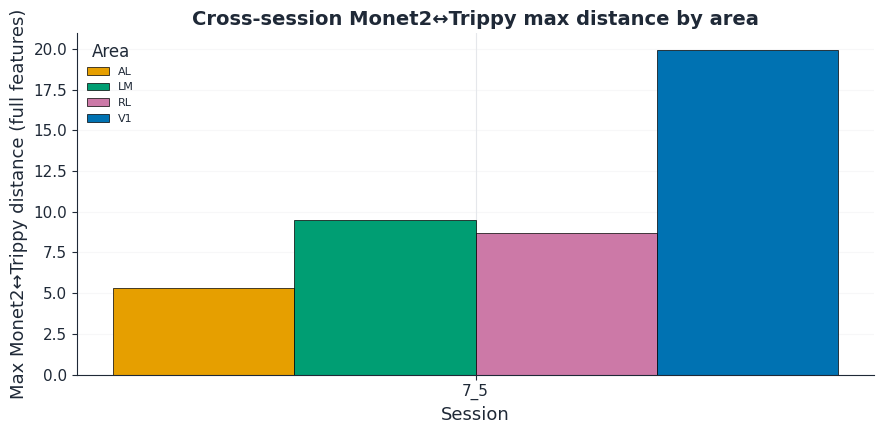

In [26]:
results_root = RESULTS_DIR.parent
session_dfs = []
for session_dir in sorted(results_root.iterdir()):
    if not session_dir.is_dir():
        continue
    csv = session_dir / "trajectory_metrics.csv"
    if csv.exists():
        df = pd.read_csv(csv)
        df["session"] = session_dir.name
        session_dfs.append(df)

if session_dfs:
    cross_df = pd.concat(session_dfs, ignore_index=True)
    cross_df = cross_df[cross_df["analysis"] == "all_neurons"]
    cross_csv = results_root / "cross_session_summary.csv"
    cross_df.to_csv(cross_csv, index=False)
    print(f"found {cross_df['session'].nunique()} session(s), wrote {cross_csv}")

    # Headline plot: max Monet2↔Trippy distance per area, per session.
    sub = cross_df[
        (cross_df["pair"] == "Monet2/Trippy") &
        (cross_df["metric"] == "full")
    ]
    if len(sub) > 0:
        fig, ax = plt.subplots(figsize=(9, 4.5))
        sessions = sorted(sub["session"].unique())
        areas = sorted(sub["area"].unique())
        x = np.arange(len(sessions))
        bw = 0.8 / max(len(areas), 1)
        palette = {"V1": "#0072B2", "AL": "#E69F00", "LM": "#009E73", "RL": "#CC79A7"}
        for i, area in enumerate(areas):
            vals = []
            for s in sessions:
                row = sub[(sub["session"] == s) & (sub["area"] == area)]
                vals.append(row["max_distance_observed"].iloc[0] if len(row) else np.nan)
            offset = (i - (len(areas) - 1) / 2) * bw
            ax.bar(x + offset, vals, width=bw, color=palette[area],
                   edgecolor="black", linewidth=0.5, label=area)
        ax.set_xticks(x)
        ax.set_xticklabels(sessions)
        ax.set_xlabel("Session")
        ax.set_ylabel("Max Monet2↔Trippy distance (full features)")
        ax.set_title("Cross-session Monet2↔Trippy max distance by area")
        ax.legend(loc="best", fontsize=8, title="Area")
        ax.grid(True, alpha=0.3, axis="y")
        fig.tight_layout()
        fig.savefig(FIGURES_DIR / "10_cross_session.png", dpi=150)
        plt.show()
else:
    print("no per-session CSVs found; cross-session aggregation is a no-op for now")

## Part 11: Takeaways

In [27]:
# Headline numbers per area: read from the CSV rows written above so the
# README can never disagree with trajectory_metrics.csv.
head = results_df[(results_df["analysis"] == "all_neurons") & (results_df["metric"] == "full")]
head_m2t = head[head["pair"] == "Monet2/Trippy"].set_index("area")

def _fmt_onset(row):
    return f"{row['onset_ms']:.0f}" if pd.notna(row["onset_ms"]) else "n/a"

for area in ["V1", "AL", "LM", "RL"]:
    r = head_m2t.loc[area]
    sig = "✓" if r["p_holm"] < 0.05 else "✗"
    print(f"{area:5s}  n={int(r['n_neurons']):5d}  Monet2↔Trippy max={r['max_distance_observed']:.3f}  "
          f"cv={r['max_distance_cv']:.3f}  null95={r['max_distance_null_p95']:.3f}  "
          f"p={r['empirical_p_value']:.3f}  p_holm={r['p_holm']:.3f} {sig}  onset={_fmt_onset(r)} ms")

summary_path = RESULTS_DIR / "README.md"
with open(summary_path, "w") as f:
    f.write(f"# Experiment 2, session {SESSION} headline numbers\n\n")
    f.write(f"Preprocessing: detrend → z-score; truncate to {N_FRAMES_TRUNCATE} frames; "
            f"running-outlier filter (|treadmill| > {TREADMILL_OUTLIER_THRESHOLD}) → "
            f"{len(clean_trial_indices)} clean trials.\n")
    f.write(f"Class composition (clean): {pd.Series(labels).value_counts().to_dict()}.\n")
    f.write(f"Null: {N_SHUFFLES} label permutations of the max-over-frames distance; "
            f"p_holm = Holm over the 12 (area × pair) tests of the full-feature metric. "
            f"`max distance` is the raw value (noise floor sqrt(N·(1/n_A+1/n_B))); "
            f"`cv distance` is the split-half bias-corrected value. "
            f"Onset = first frame at which the observed distance exceeds the null's 95th "
            f"percentile; only reported when p_holm < 0.05.\n\n")
    f.write("## Headline: Monet2↔Trippy by area (full-feature metric)\n\n")
    f.write("| Area | n_neurons | max distance | cv distance | null p95 | p | p_holm | onset (ms) |\n")
    f.write("|---|---|---|---|---|---|---|---|\n")
    for area in ["V1", "AL", "LM", "RL"]:
        r = head_m2t.loc[area]
        f.write(f"| {area} | {int(r['n_neurons'])} | {r['max_distance_observed']:.3f} | "
                f"{r['max_distance_cv']:.3f} | {r['max_distance_null_p95']:.3f} | "
                f"{r['empirical_p_value']:.3f} | {r['p_holm']:.3f} | {_fmt_onset(r)} |\n")
print(f"\nwrote {summary_path}")


V1     n= 5485  Monet2↔Trippy max=19.960  cv=12.449  null95=21.460  p=0.338  p_holm=1.000 ✗  onset=n/a ms
AL     n=  414  Monet2↔Trippy max=5.305  cv=3.163  null95=6.170  p=0.776  p_holm=1.000 ✗  onset=n/a ms
LM     n= 1262  Monet2↔Trippy max=9.478  cv=5.924  null95=10.617  p=0.533  p_holm=1.000 ✗  onset=n/a ms
RL     n= 1033  Monet2↔Trippy max=8.675  cv=5.934  null95=9.283  p=0.308  p_holm=1.000 ✗  onset=n/a ms

wrote results/exp2_stim_trajectories/7_5/README.md


### Conclusions

**Monet2↔Trippy verdict per area.**
Under the full-feature test with 1000 label permutations and Holm correction over the 12 area × pair tests, **no pair in any area reaches p_holm < 0.05**. Monet2↔Trippy: uncorrected p = 0.34 (V1), 0.78 (AL), 0.53 (LM), 0.31 (RL); observed maxima below the null 95th percentiles everywhere. The only pairs that approach significance are Clip↔Trippy in RL (raw p = 0.010, p_holm 0.12) and in V1 (raw 0.029, p_holm 0.32). No onset latency is reported. The top-3-PC test is significant everywhere but is biased by fitting PCA on the class means being compared, so it is not used for any verdict.

**Raw versus bias-corrected distances.**
The ordering of the raw distances (Monet2↔Trippy largest, Clip↔Monet2 smallest, in every area) is the ordering of their sampling-noise floors `sqrt(N·(1/n_A + 1/n_B))`, i.e. of the trial counts, not of the brain. The split-half bias-corrected distances (V1: 12.4 Monet2↔Trippy, 11.3 Clip↔Trippy, 9.9 Clip↔Monet2) are the quantities to compare across pairs and, at matched population, across areas.

**Equal-population control.**
V1's larger raw distances in Part 7 were its neuron count. At 414 neurons the four areas give bias-corrected Monet2↔Trippy maxima of 3.7 (V1), 3.8 (LM), 3.7 (RL) and 3.2 (AL, unsubsampled), with no per-subsample null; the areas are indistinguishable on this quantity.

**Clip-subsampling control.**
Dropping Clip to 38 trials inflates the raw Clip↔parametric distances (14.6 → 20.1, 17.1 → 21.1) while the bias-corrected ones move by less than 0.7. The unequal trial counts do not create or hide a Clip-versus-parametric difference.

**Qualitative shape of the trajectories.**
Within the top-3 PC projection each class-mean trajectory jumps away from a shared starting point over the first few frames and then stays within its own region for the rest of the 10 s trial; the frame markers bunch together. This projection was fit on the three class means, so their separation in it is expected; the temporal shape (an onset transient, then a plateau) is the descriptive content.

**What was and was not shown.**
Experiment 1 showed that stimulus class is linearly decodable from the trial-averaged activity of every area. This experiment shows that the *distance between class-mean trajectories*, tested in the full neuron space against a permutation null, does not separate any pair at the family-wise 5 % level in any of the four areas — for Monet2↔Trippy not even at the uncorrected level. The two results are compatible: a decoder finds separating directions that a Euclidean distance between class means, dominated by the `sqrt(N/n)` noise of 38-trial averages, does not resolve. "Clip versus the two parametric stimuli" is a difference between stimulus sets whose low-level statistics were not controlled; "uniformity across areas" was not tested — the same null outcome in four areas of one session is all that can be said; and whether a nonlinear method would separate Monet2 from Trippy was not tested in this repository.


## Presentation figure: 2×2 trajectory grid

Slide-deck layout: per-area trial-averaged trajectories in PC1–PC2 space, one panel per cortical area. Minimal chrome, thin grey border, area + neuron count in the corner, three coloured trajectories, no per-panel legend or axis labels. A single shared colour key lives at the bottom of the figure.

Saved to `figures/exp2_stim_trajectories/{SESSION}/trajectories_2x2.png`.

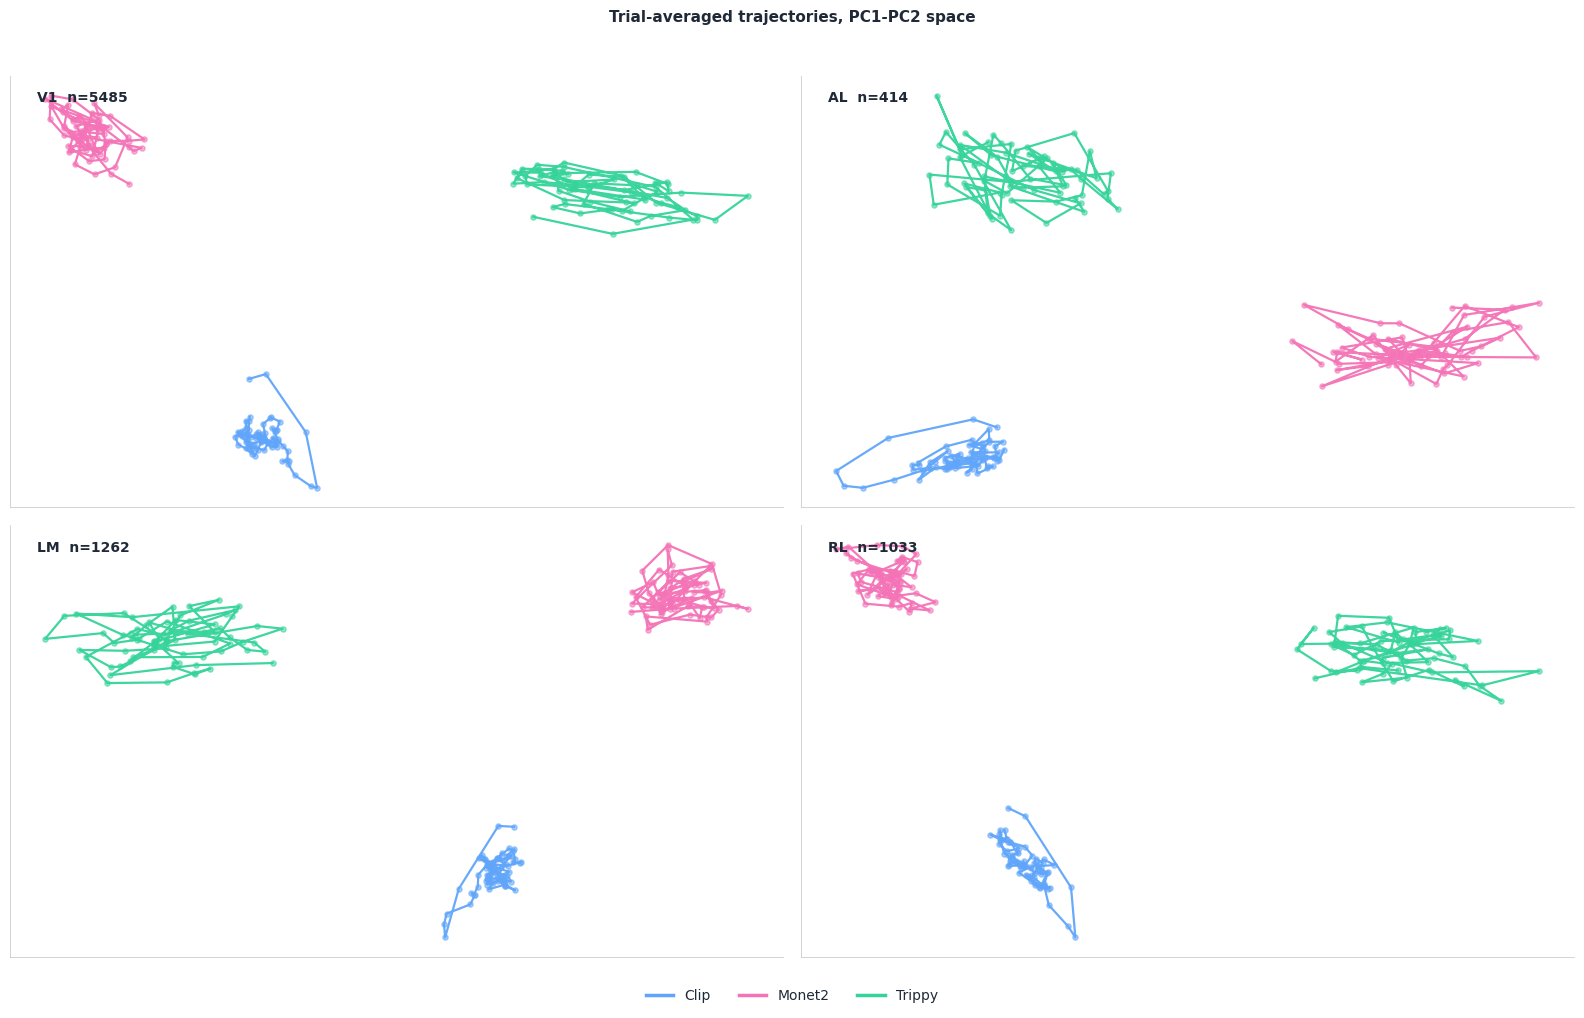

In [28]:
# 2×2 grid of per-area trajectories (PC1-PC2): slide-deck layout.
STIM_COLORS, STIM_ORDER = pca_utils.STIM_COLORS, pca_utils.STIM_ORDER

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, area in zip(axes.flat, ["V1", "AL", "LM", "RL"]):
    res = all_area_results[area]
    stim_pcs = res["stim_pcs"]
    n_neurons = res["n_neurons"]

    for stim in STIM_ORDER:
        if stim not in stim_pcs:
            continue
        traj = stim_pcs[stim]
        ax.plot(
            traj[:, 0], traj[:, 1],
            color=STIM_COLORS[stim], linewidth=1.6, alpha=0.95,
        )
        # Subtle scatter overlay so the trajectory reads as a 'blob' on a slide.
        ax.scatter(
            traj[:, 0], traj[:, 1],
            color=STIM_COLORS[stim], s=14, alpha=0.55,
        )

    # Subtle thin border on all four sides.
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
        spine.set_color("#cccccc")

    # Strip axis chrome.
    ax.set_xticks([])
    ax.set_yticks([])

    # Area + neuron count in the top-left of the panel.
    ax.text(
        0.035, 0.965, f"{area}  n={n_neurons}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10, fontweight="bold",
    )

# Figure-level title (small chart title, not a slide title).
fig.suptitle("Trial-averaged trajectories, PC1-PC2 space", fontsize=11, y=0.995)

# Single shared colour key at the bottom: no per-panel legends.
handles = [
    plt.Line2D([0], [0], color=STIM_COLORS[s], linewidth=2.5, label=s)
    for s in STIM_ORDER if s in stim_pcs
]
fig.legend(
    handles=handles, loc="lower center", ncol=len(handles),
    fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.01),
)

fig.tight_layout(rect=(0, 0.03, 1, 0.98))
(FIGURES_DIR / "presentation").mkdir(exist_ok=True)
fig.savefig(FIGURES_DIR / "presentation" / "trajectories_2x2.png", dpi=150, bbox_inches="tight")
plt.show()

## Presentation figure: honest-test p-values

Grouped bar chart of empirical p-values from the full-feature shuffle null, for the three stim-class pairs across the four cortical areas. Dark-theme styling with a transparent background so the figure overlays cleanly on a slide. Bars below the `p = 0.05` threshold are highlighted in coral; in this dataset only **RL · Clip↔Trippy** qualifies.

P-values are pulled live from `all_area_results` (pseudocount-1 formula), printed before plotting so they can be cross-checked against any expected values. Saved to `figures/exp2_stim_trajectories/{SESSION}/honest_test_pvalues.{svg,png}`.

Empirical p-values (full-feature, pseudocount-1):
  Clip ↔ Monet2: V1=0.53  LM=0.24  RL=0.11  AL=0.41
  Clip ↔ Trippy: V1=0.03  LM=0.11  RL=0.01  AL=0.31
  Monet2 ↔ Trippy: V1=0.34  LM=0.53  RL=0.31  AL=0.78


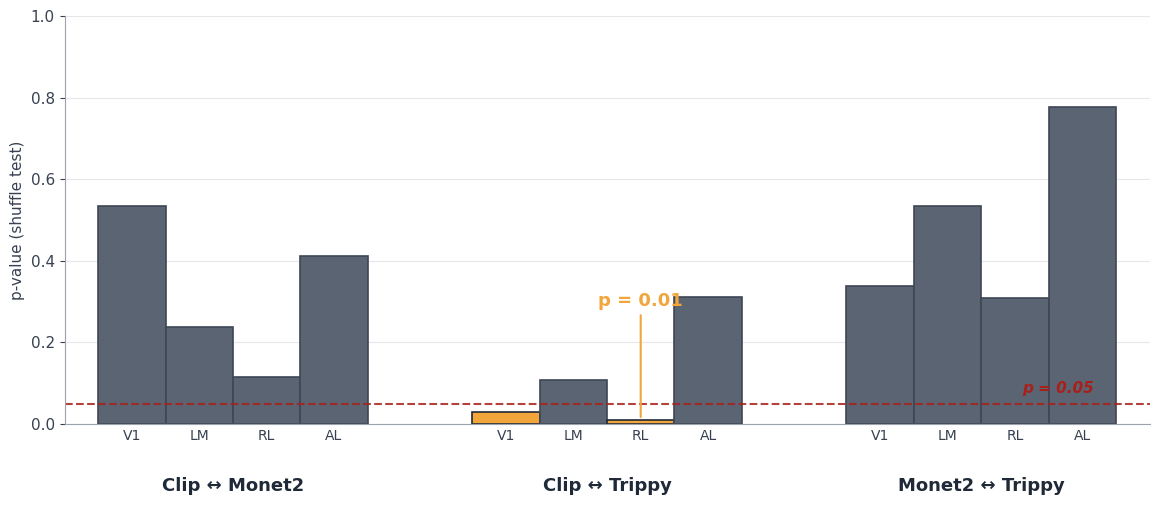

In [29]:
# Honest-test p-value bar chart for the slide deck.
# Light theme matching the reference image (slate / amber / red).
from matplotlib.transforms import blended_transform_factory

# Colors matched to the reference image.
NEUTRAL        = "#5B6472"   # slate grey-blue (non-significant bars)
NEUTRAL_EDGE   = "#3E4754"   # darker slate outline on neutral bars
HIGHLIGHT      = "#F2A53A"   # amber/gold (significant bars)
HIGHLIGHT_EDGE = "#1F2937"   # near-black outline on significant bars
THRESHOLD      = "#A8201A"   # deep red threshold line

# 1) Compute empirical p-values per (pair, area).
pair_specs = [
    ("Clip", "Monet2", "Clip ↔ Monet2"),
    ("Clip", "Trippy", "Clip ↔ Trippy"),
    ("Monet2", "Trippy", "Monet2 ↔ Trippy"),
]
PAIR_LABELS = [s[2] for s in pair_specs]
AREAS_ORDER = ["V1", "LM", "RL", "AL"]

p_values = {label: {} for _, _, label in pair_specs}
for a, b, label in pair_specs:
    pair_key = frozenset({a, b})
    for area in AREAS_ORDER:
        res = all_area_results[area]
        d = res["distances_full"][pair_key]
        null = res["null_full"][pair_key]
        obs_max = float(d.max())
        p = float((1 + (null >= obs_max).sum()) / (1 + len(null)))
        p_values[label][area] = p

print("Empirical p-values (full-feature, pseudocount-1):")
for label in PAIR_LABELS:
    row = "  ".join(f"{a}={p_values[label][a]:.2f}" for a in AREAS_ORDER)
    print(f"  {label}: {row}")

SIG_THRESHOLD = 0.05
n_groups = len(PAIR_LABELS)
n_per_group = len(AREAS_ORDER)
bar_width = 0.18
offsets = (np.arange(n_per_group) - (n_per_group - 1) / 2) * bar_width

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# 2) Bars: every bar gets an outline; significant bars get a darker one.
bar_positions, bar_areas = [], []
for i, label in enumerate(PAIR_LABELS):
    for j, area in enumerate(AREAS_ORDER):
        x = i + offsets[j]
        h = p_values[label][area]
        is_sig = h < SIG_THRESHOLD
        ax.bar(
            x, h, width=bar_width,
            color=HIGHLIGHT if is_sig else NEUTRAL,
            edgecolor=HIGHLIGHT_EDGE if is_sig else NEUTRAL_EDGE,   # ← outline ALL bars
            linewidth=1.2,                                          # ← uniform line weight
        )
        bar_positions.append(x)
        bar_areas.append(area)

# 3) Threshold line + right-aligned BOLD ITALIC label.
ax.axhline(SIG_THRESHOLD, color=THRESHOLD, linestyle="--", linewidth=1.5, alpha=0.85)
ax.text(
    n_groups - 1 + 0.3, SIG_THRESHOLD + 0.018, "p = 0.05",   # ← position controlled here
    color=THRESHOLD, fontsize=11,
    fontstyle="italic", fontweight="bold",                    # ← bold italic
    ha="right", va="bottom",
)

# 4) Significant-bar callout (amber, bold, with thin connecting line).
sig_label = "Clip ↔ Trippy"
sig_area  = "RL"
sig_p = p_values[sig_label][sig_area]
if sig_p < SIG_THRESHOLD:
    sig_x = PAIR_LABELS.index(sig_label) + offsets[AREAS_ORDER.index(sig_area)]
    ax.annotate(
        f"p = {sig_p:.2f}",
        xy=(sig_x, sig_p),
        xytext=(sig_x, sig_p + 0.28),
        ha="center", fontsize=13, fontweight="bold", color=HIGHLIGHT,
        arrowprops=dict(arrowstyle="-", color=HIGHLIGHT, lw=1.5),
    )

# 5) Y-axis.
ax.set_ylim(0, 1.0)
ax.set_ylabel("p-value (shuffle test)", fontsize=11, color="#374151")

# Horizontal grid only, behind bars.
ax.yaxis.grid(True, color="#E5E7EB", linewidth=0.8)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# Hide top/right spines, soften the rest.
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#9CA3AF")
ax.spines["bottom"].set_color("#9CA3AF")
ax.tick_params(colors="#374151")

# 6) Per-bar area labels (V1/LM/RL/AL).
ax.set_xticks(bar_positions)
ax.set_xticklabels(bar_areas, fontsize=10, color="#374151")
ax.tick_params(axis="x", length=0)
ax.set_xlim(-0.45, n_groups - 1 + 0.45)

# 7) Pair labels below the area labels (bolder, larger).
trans = blended_transform_factory(ax.transData, ax.transAxes)
for i, label in enumerate(PAIR_LABELS):
    ax.text(
        i, -0.13, label,
        transform=trans,
        ha="center", va="top",
        fontsize=13, fontweight="bold", color="#1F2937",
    )

plt.subplots_adjust(bottom=0.20)
(FIGURES_DIR / "presentation").mkdir(exist_ok=True)
fig.savefig(
    FIGURES_DIR / "presentation" / "honest_test_pvalues.svg",
    format="svg", bbox_inches="tight", facecolor="white",
)
fig.savefig(
    FIGURES_DIR / "presentation" / "honest_test_pvalues.png",
    dpi=300, bbox_inches="tight", facecolor="white",
)
plt.show()

## Presentation figure: simple 2×2 trajectory grid

Plain 2×2 grid: one `plot_trajectory_2d` panel per cortical area (V1, AL, LM, RL), with all the helper's default chrome (axis labels, variance %, frame markers, time annotations, per-panel legend). No extra styling on top, just calls the existing helper four times.

Saved as SVG (and PNG) to `figures/exp2_stim_trajectories/{SESSION}/presentation/`.

saved trajectories_2x2_simple.svg + .png to figures/exp2_stim_trajectories/7_5/presentation


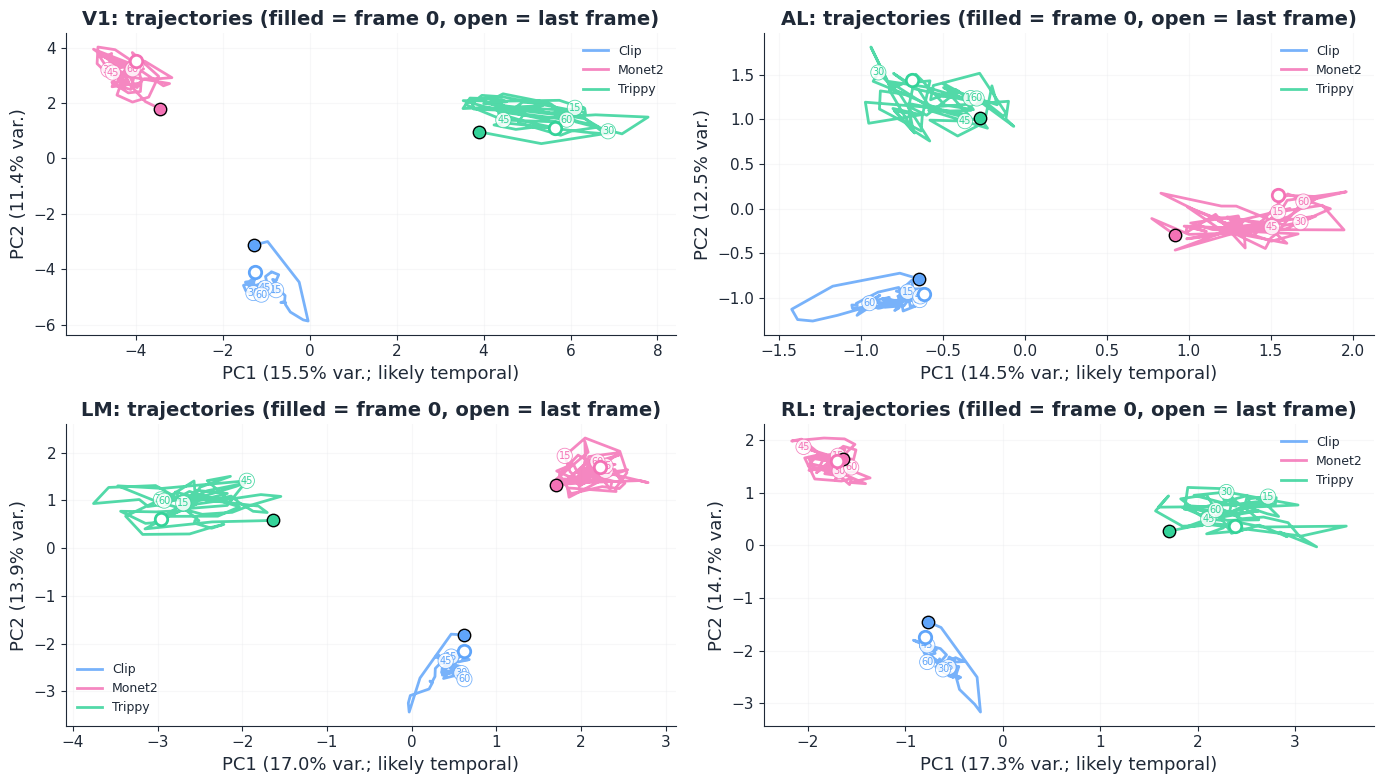

In [30]:
# Simple 2x2 grid of plot_trajectory_2d, one per cortical area.

PRESENTATION_DIR = FIGURES_DIR / "presentation"
PRESENTATION_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.patch.set_facecolor("white")                    # ← figure background

for ax, area in zip(axes.flat, ["V1", "AL", "LM", "RL"]):
    res = all_area_results[area]
    traj_utils.plot_trajectory_2d(
        res["stim_pcs"], area, res["pca"], ax=ax,
    )
    ax.set_facecolor("white")                       # ← per-axis background

fig.tight_layout()

fig.savefig(PRESENTATION_DIR / "trajectories_2x2_simple.svg",
            format="svg", bbox_inches="tight",
            facecolor="white")                      # ← force white on SVG
fig.savefig(PRESENTATION_DIR / "trajectories_2x2_simple.png",
            dpi=150, bbox_inches="tight",
            facecolor="white")                      # ← force white on PNG

print(f"saved trajectories_2x2_simple.svg + .png to {PRESENTATION_DIR}")
plt.show()

## Presentation figure: population-control bar chart

Grouped bar chart for the slide deck: per-area Monet2 ↔ Trippy max trajectory distance, full-population (left) vs matched-population (right, subsampled to AL's neuron count). Pulled live from `all_area_results` + `matched_results`: no hardcoded heights. Saved as SVG + PNG to `figures/exp2_stim_trajectories/{SESSION}/presentation/`.

findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font f

saved population_control.svg + .png to figures/exp2_stim_trajectories/7_5/presentation


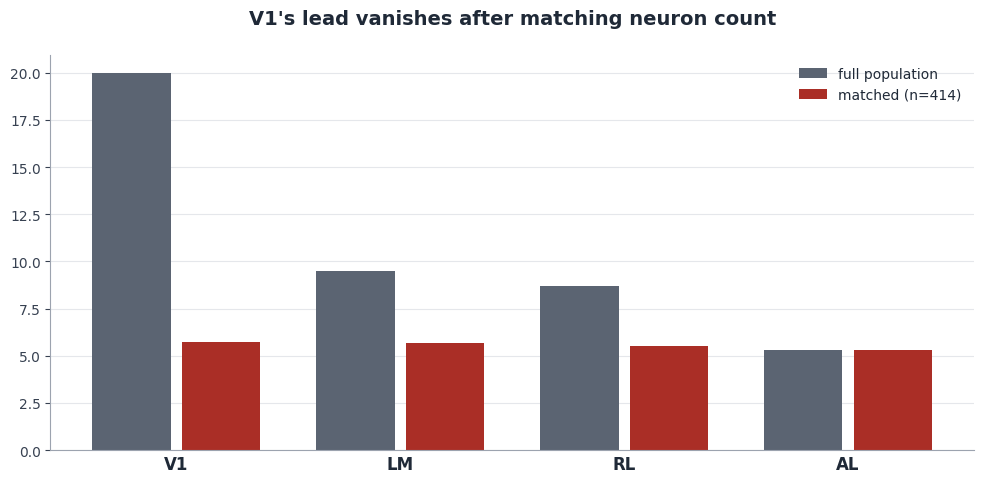

In [31]:
# Population-control bar chart (Monet2 ↔ Trippy headline pair).
# Edit PAIR_KEY below if you want a different pair.

plt.rcParams["font.family"] = ["Inter", "DejaVu Sans", "sans-serif"]

PRESENTATION_DIR = FIGURES_DIR / "presentation"
PRESENTATION_DIR.mkdir(parents=True, exist_ok=True)

PAIR_KEY = frozenset({"Monet2", "Trippy"})
AREAS = ["V1", "LM", "RL", "AL"]
n_match = all_area_results["AL"]["n_neurons"]

# Full-population max distance per area.
full_heights = [
    float(all_area_results[area]["distances_full"][PAIR_KEY].max())
    for area in AREAS
]

# Matched-population max distance per area:
# - V1/LM/RL: median across the 20 subsamples of the per-subsample max distance.
# - AL: single identity entry (already at n_match), so median == its own value.
matched_heights = []
for area in AREAS:
    subs = matched_results[area]
    per_sub_max = np.array(
        [s["distances_full"][PAIR_KEY].max() for s in subs]
    )
    matched_heights.append(float(np.median(per_sub_max)))

# Colours.
FULL_COLOR    = "#5B6472"   # slate grey-blue
MATCHED_COLOR = "#AA2E26"   # deep red (user-specified)

# Layout.
n_groups = len(AREAS)
group_centers = np.arange(n_groups, dtype=float) * 1.0
bar_width = 0.35
offset = 0.20
full_x    = group_centers - offset
matched_x = group_centers + offset

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.bar(
    full_x, full_heights, width=bar_width, color=FULL_COLOR,
    edgecolor="none", label="full population",
)
ax.bar(
    matched_x, matched_heights, width=bar_width, color=MATCHED_COLOR,
    edgecolor="none", label=f"matched (n={n_match})",
)

# Title + subtitle.                                              # ← NEW
ax.set_title(                                                    # ← NEW
    "V1's lead vanishes after matching neuron count",            # ← NEW
    fontsize=14, fontweight="bold", color="#1F2937",             # ← NEW
    loc="center", pad=22,                                          # ← NEW
)                                                                # ← NEW
                                                              # ← NEW

# Spines + ticks.
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#9CA3AF")
ax.spines["bottom"].set_color("#9CA3AF")

# Horizontal grid only, behind bars.
ax.yaxis.grid(True, color="#E5E7EB", linewidth=0.8)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# X-axis area labels: bold, larger.
ax.set_xticks(group_centers)
ax.set_xticklabels(AREAS, fontsize=12, fontweight="bold", color="#1F2937")
ax.tick_params(axis="x", length=0)

# Y-axis.
ax.tick_params(axis="y", colors="#374151", labelsize=10)
ax.set_ylim(bottom=0)

# Legend: inside top-right, no frame.
ax.legend(loc="upper right", frameon=False, fontsize=10)

fig.tight_layout()

fig.savefig(
    PRESENTATION_DIR / "population_control.svg",
    format="svg", bbox_inches="tight", facecolor="white",
)
fig.savefig(
    PRESENTATION_DIR / "population_control.png",
    dpi=300, bbox_inches="tight", facecolor="white",
)
print(f"saved population_control.svg + .png to {PRESENTATION_DIR}")
plt.show()